# LEAF Structure & Diurnal Dynamics – DE-Har

Targeted analysis of LEAF hemi-hi scans for the SPAC cascade study.

**Products:**
1. Predawn Pgap(z) time series at key heights (5 m, 10 m, 13 m, 20 m)
2. Overstory transmission ratio Pgap(20m)/Pgap(13m)
3. Total PAI via solid-angle weighted method
4. Cumulative PAI profiles (monthly snapshots)
5. Diurnal Pgap amplitude (afternoon − predawn) as a wilting indicator

In [1]:
import os
import re
import glob
import time
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from pylidar_tls_canopy import leaf_io, plant_profile

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

RIEGL RDBlib is not available
RIEGL RiVlib is not available


## Settings

In [2]:
# --- Paths ---
PROJECT_ROOT = Path().resolve().parents[1]
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "proximal_rs" / "leaf"

# --- Instrument ---
SENSOR_ID = 320
SENSOR_HEIGHT = 1.5  # metres above ground
ZENITH_OFFSET = 0    # radians

# --- Profile parameters ---
HRES = 0.5       # vertical bin (m)
MAX_H = 25       # max height (m)
MIN_ZENITH = 5   # degrees
MAX_ZENITH = 70  # degrees
ZRES = 5         # zenith bin (deg)
ARES = 45        # azimuth bin (deg)
METHOD = 'FIRSTLAST'

# --- Time selection (UTC hours) ---
# DE-Har hemi-hi schedule: every 3h
# CET (UTC+1): local 21,00,03,06,09,12,15,18 → UTC 20,23,02,05,08,11,14,17
# CEST (UTC+2): local same → UTC 19,22,01,04,07,10,13,16
PREDAWN_HOUR = 8    # UTC → ~06:00 CET / ~07:00 CEST
AFTERNOON_HOUR = 17  # UTC → ~15:00 CET / ~16:00 CEST

# --- Heights to extract Pgap ---
Z_LEVELS = [5, 10, 13, 20]

## Meteorological data for quality filtering

In [3]:
# --- Paths to met data ---
MET_FILE = PROJECT_ROOT / "data/processed/atmosphere_soil/meteo_dehar_30min.csv"          # <-- CHANGE
PRECIP_FILE = PROJECT_ROOT / "data/processed/atmosphere_soil/HARTHM_2025_Precipitation_30min_UTC.csv"  # <-- CHANGE

# --- Quality thresholds ---
PRECIP_WINDOW_H = 3    # hours before scan start: reject if any rain in this window
PRECIP_THRESH_MM = 0.2 # minimum cumulative precip (mm) to flag as rain
RH_THRESH_PCT = 97    # relative humidity above this → dew/fog risk
USTAR_THRESH_MS = 0.8  # friction velocity above this → high wind
SCAN_DURATION_MIN = 45 # hemi-hi scan duration (minutes), used to define the scan window

In [4]:
# Load met data
met = pd.read_csv(MET_FILE, parse_dates=['datetime'])
met['datetime'] = pd.to_datetime(met['datetime'], utc=True)
met = met.set_index('datetime').sort_index()

# Load precipitation
precip = pd.read_csv(PRECIP_FILE)
precip['datetime'] = pd.to_datetime(
    precip['From'].str.replace('Z', '+00:00'), utc=True)
precip = precip.set_index('datetime')[['Precipitation_Sum_mm']].sort_index()

# Merge into single met DataFrame
met_full = met.join(precip, how='outer')
met_full['Precipitation_Sum_mm'] = met_full['Precipitation_Sum_mm'].fillna(0)

print(f'Met data: {met_full.index.min()} → {met_full.index.max()}')
print(f'Columns: {list(met_full.columns)}')

Met data: 2024-11-30 23:30:00+00:00 → 2025-12-31 23:30:00+00:00
Columns: ['tair_c', 'rh_pct', 'vpd_hpa', 'rg_wm2', 'par_umol_m2s', 'ustar_ms', 'Precipitation_Sum_mm']


In [102]:
def quality_flag_scan(scan_dt, met_df, scan_duration_min=SCAN_DURATION_MIN):
    """Flag scan quality based on meteorological conditions.
    
    Checks conditions during the scan AND a preceding window.
    
    Parameters
    ----------
    scan_dt : datetime
        Scan start time (UTC).
    met_df : pd.DataFrame
        Merged met data with DatetimeIndex (UTC).
    
    Returns
    -------
    flags : dict
        Boolean flags (True = problem) and met values during scan.
    """
    scan_start = pd.Timestamp(scan_dt, tz='UTC')
    scan_end = scan_start + pd.Timedelta(minutes=scan_duration_min)
    precip_start = scan_start - pd.Timedelta(hours=PRECIP_WINDOW_H)
    
    # Window: precip lookback to scan end
    precip_window = met_df.loc[precip_start:scan_end, 'Precipitation_Sum_mm']
    scan_window = met_df.loc[scan_start:scan_end]
    
    if scan_window.empty:
        return {'valid': False, 'reason': 'no_met_data'}
    
    # Precipitation: any rain in the lookback + scan window
    precip_total = precip_window.sum()
    flag_rain = precip_total >= PRECIP_THRESH_MM
    
    # Humidity: mean RH during scan
    rh_mean = scan_window['rh_pct'].mean()
    flag_humid = rh_mean >= RH_THRESH_PCT
    
    # Wind: max ustar during scan
    ustar_max = scan_window['ustar_ms'].max()
    flag_wind = ustar_max >= USTAR_THRESH_MS
    
    # VPD and temperature during scan (for context, not filtering)
    vpd_mean = scan_window['vpd_hpa'].mean()
    tair_mean = scan_window['tair_c'].mean()
    
    good = not (flag_rain or flag_humid or flag_wind)
    
    reason = []
    if flag_rain: reason.append(f'rain({precip_total:.1f}mm)')
    if flag_humid: reason.append(f'humid(RH={rh_mean:.0f}%)')
    if flag_wind: reason.append(f'wind(u*={ustar_max:.2f})')
    
    return {
        'valid': True,
        'good': good,
        'reason': ', '.join(reason) if reason else 'ok',
        'flag_rain': flag_rain,
        'flag_humid': flag_humid,
        'flag_wind': flag_wind,
        'precip_mm': precip_total,
        'rh_mean': rh_mean,
        'ustar_max': ustar_max,
        'vpd_mean': vpd_mean,
        'tair_mean': tair_mean,
    }

print('Quality filter ready. Thresholds:')
print(f'  Rain:     ≥{PRECIP_THRESH_MM} mm in {PRECIP_WINDOW_H}h before + during scan')
print(f'  Humidity: RH ≥ {RH_THRESH_PCT}% during scan')
print(f'  Wind:     u* ≥ {USTAR_THRESH_MS} m/s during scan')

Quality filter ready. Thresholds:
  Rain:     ≥0.2 mm in 3h before + during scan
  Humidity: RH ≥ 97% during scan
  Wind:     u* ≥ 0.8 m/s during scan


## Discover and group files

In [6]:
hemi_hi_files = sorted(DATA_DIR.glob('ESS?????_*_hemi_*_0800_0400.csv'))
print(f'Total hemi-hi files: {len(hemi_hi_files)}')

# Parse UTC hour from filename
def get_utc_hour(fn):
    m = re.search(r'(\d{8})-(\d{2})(\d{2})(\d{2})Z', fn.name)
    if m:
        return int(m.group(2))
    return None

def get_datetime(fn):
    m = re.search(r'(\d{8})-(\d{6})Z', fn.name)
    if m:
        return datetime.datetime.strptime(m.group(1) + m.group(2), '%Y%m%d%H%M%S')
    return None

# Group by hour
hour_counts = {}
for f in hemi_hi_files:
    h = get_utc_hour(f)
    hour_counts[h] = hour_counts.get(h, 0) + 1

print('\nUTC hour  |  N scans')
for h in sorted(hour_counts):
    marker = ' ← predawn' if h == PREDAWN_HOUR else (' ← afternoon' if h == AFTERNOON_HOUR else '')
    print(f'  {h:02d}:00    |  {hour_counts[h]:>4d}{marker}')

# Filter
predawn_files = [f for f in hemi_hi_files if get_utc_hour(f) == PREDAWN_HOUR]
afternoon_files = [f for f in hemi_hi_files if get_utc_hour(f) == AFTERNOON_HOUR]
print(f'\nPredawn ({PREDAWN_HOUR:02d} UTC): {len(predawn_files)} files')
print(f'Afternoon ({AFTERNOON_HOUR:02d} UTC): {len(afternoon_files)} files')

Total hemi-hi files: 1940

UTC hour  |  N scans
  02:00    |   243
  05:00    |   243
  08:00    |   243 ← predawn
  11:00    |   241
  14:00    |   242
  17:00    |   242 ← afternoon
  20:00    |   243
  23:00    |   243

Predawn (08 UTC): 243 files
Afternoon (17 UTC): 242 files


## Core processing function

In [8]:
predawn_files[0]

PosixPath('/mnt/data/lk1167/projects/dehar-spac/data/raw/proximal_rs/leaf/ESS00320_0024_hemi_20250417-081031Z_0800_0400.csv')

In [9]:
vpp = plant_profile.Jupp2009(
        hres=HRES, zres=ZRES, ares=ARES,
        min_z=MIN_ZENITH, max_z=MAX_ZENITH,
        min_h=0, max_h=MAX_H)

valid = vpp.add_leaf_scan_position(
        str(predawn_files[0]), method=METHOD,
        min_zenith=MIN_ZENITH, max_zenith=MAX_ZENITH,
        sensor_height=SENSOR_HEIGHT,
        zenith_offset=ZENITH_OFFSET)

In [11]:
pgap = vpp.get_pgap_theta_z()

In [26]:
len(vpp.pgap_theta_z)

13

In [27]:
vpp.exportPlantProfiles()

,Height,HingePAI,LinearPAI,LinearMLA,WeightedPAI,HingePAVD,LinearPAVD,WeightedPAVD
0,0.0,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.5,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1.0,-0.000000,0.000000,0.000000,0.000000,0.001584,0.001435,0.001340
3,1.5,0.001584,0.001435,89.048210,0.001340,0.008776,0.014397,0.020429
4,2.0,0.008776,0.014397,90.000000,0.020429,0.071453,0.049440,0.074968
5,2.5,0.073038,0.050875,90.000000,0.076308,0.157267,0.120973,0.160499
6,3.0,0.166043,0.135370,90.000000,0.180929,0.251015,0.317128,0.271774
7,3.5,0.324053,0.368003,90.000000,0.348082,0.334065,0.519242,0.364095
8,4.0,0.500108,0.654612,90.000000,0.545024,0.519773,0.487104,0.400536
9,4.5,0.843826,0.855106,90.000000,0.748617,0.620071,0.430259,0.449494


In [28]:
vpp.exportPgapProfiles()

,Height,Zenith0075,Zenith0125,Zenith0175,Zenith0225,Zenith0275,Zenith0325,Zenith0375,Zenith0425,Zenith0475,Zenith0525,Zenith0575,Zenith0625,Zenith0675
0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.5,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,1.5,0.999209,0.999451,0.999491,0.999830,0.999435,0.999494,0.999548,0.999720,0.999177,0.999433,0.998561,0.998134,0.997234
4,2.0,0.998019,0.997681,0.997283,0.998813,0.997398,0.997649,0.997850,0.998107,0.998230,0.998302,0.992054,0.969048,0.898870
5,2.5,0.995643,0.996137,0.995531,0.997232,0.995418,0.995402,0.987174,0.980274,0.976206,0.966262,0.935758,0.839331,0.761197
6,3.0,0.994057,0.995172,0.995136,0.996388,0.970480,0.949141,0.902742,0.909278,0.916051,0.877782,0.859892,0.714522,0.615736
7,3.5,0.932238,0.946990,0.940082,0.952439,0.899473,0.886479,0.867799,0.849486,0.808072,0.777874,0.744834,0.580354,0.441202
8,4.0,0.904398,0.863565,0.851299,0.852480,0.806233,0.790242,0.797629,0.776482,0.744065,0.694755,0.634674,0.422489,0.334010
9,4.5,0.900651,0.853765,0.832005,0.798742,0.740880,0.703455,0.703147,0.675579,0.669384,0.568814,0.464351,0.326319,0.261579


In [104]:
def process_scan(filepath):
    """Process a single hemi-hi scan.
    
    Returns dict with:
    - datetime
    - pgap_z: full Pgap profile (zenith-averaged)
    - pgap_at: dict of Pgap values at Z_LEVELS
    - pai_weighted: weighted PAI profile
    - pai_total: total PAI (max of cumulative profile)
    - height_bin: height axis
    - overstory_ratio: Pgap(20m)/Pgap(13m)
    """
    vpp = plant_profile.Jupp2009(
        hres=HRES, zres=ZRES, ares=ARES,
        min_z=MIN_ZENITH, max_z=MAX_ZENITH,
        min_h=0, max_h=MAX_H)
    
    valid = vpp.add_leaf_scan_position(
        str(filepath), method=METHOD,
        min_zenith=MIN_ZENITH, max_zenith=MAX_ZENITH,
        sensor_height=SENSOR_HEIGHT,
        zenith_offset=ZENITH_OFFSET)
    
    if not valid:
        return None
    
    vpp.get_pgap_theta_z()
    h = vpp.height_bin
    
    # Zenith-averaged Pgap profile
    pgap_z = np.nanmean(vpp.pgap_theta_z, axis=0)
    
    # Pgap at specific heights
    pgap_at = {}
    for z in Z_LEVELS:
        idx = np.argmin(np.abs(h - z))
        pgap_at[z] = pgap_z[idx]
    
    # Overstory transmission ratio
    idx13 = np.argmin(np.abs(h - 13))
    idx20 = np.argmin(np.abs(h - 20))
    p13 = pgap_z[idx13]
    p20 = pgap_z[idx20]
    overstory_ratio = p20 / p13 if p13 > 0 else np.nan
    
    # Weighted PAI
    pai_weighted = vpp.calcSolidAnglePlantProfiles()
    
    return {
        'datetime': vpp.datetime,
        'pgap_z': pgap_z,
        'pgap_at': pgap_at,
        'pai_weighted': pai_weighted,
        'pai_total': np.max(pai_weighted),
        'height_bin': h,
        'overstory_ratio': overstory_ratio,
        'overstory_interception': 1 - overstory_ratio,
    }

## Process predawn scans

In [105]:
predawn_results = []
t0 = time.time()

for i, f in enumerate(predawn_files):
    try:
        # Quality check from met data
        scan_dt = get_datetime(f)
        qf = quality_flag_scan(scan_dt, met_full)
        
        r = process_scan(f)
        if r is not None:
            r['qf'] = qf
            predawn_results.append(r)
    except Exception as e:
        print(f'  Error {f.name}: {e}')
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(predawn_files)} ({time.time()-t0:.0f}s)')

n_good = sum(1 for r in predawn_results if r['qf'].get('good', False))
n_rain = sum(1 for r in predawn_results if r['qf'].get('flag_rain', False))
n_humid = sum(1 for r in predawn_results if r['qf'].get('flag_humid', False))
n_wind = sum(1 for r in predawn_results if r['qf'].get('flag_wind', False))
print(f'\nPredawn: {len(predawn_results)} processed in {time.time()-t0:.0f}s')
print(f'  Good:    {n_good}')
print(f'  Rain:    {n_rain}')
print(f'  Humid:   {n_humid}')
print(f'  Wind:    {n_wind}')

  50/243 (17s)
  100/243 (33s)
  150/243 (49s)
  200/243 (66s)

Predawn: 243 processed in 80s
  Good:    164
  Rain:    32
  Humid:   43
  Wind:    20


## Process afternoon scans

In [106]:
afternoon_results = []
t0 = time.time()

for i, f in enumerate(afternoon_files):
    try:
        scan_dt = get_datetime(f)
        qf = quality_flag_scan(scan_dt, met_full)
        
        r = process_scan(f)
        if r is not None:
            r['qf'] = qf
            afternoon_results.append(r)
    except Exception as e:
        print(f'  Error {f.name}: {e}')
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(afternoon_files)} ({time.time()-t0:.0f}s)')

n_good = sum(1 for r in afternoon_results if r['qf'].get('good', False))
print(f'\nAfternoon: {len(afternoon_results)} processed, {n_good} good, '
      f'in {time.time()-t0:.0f}s')

  50/242 (16s)
  100/242 (33s)
  150/242 (49s)
  200/242 (66s)

Afternoon: 242 processed, 201 good, in 79s


## Build time series DataFrames

In [107]:
def results_to_df(results):
    """Convert list of result dicts to a DataFrame."""
    records = []
    for r in results:
        qf = r.get('qf', {})
        row = {
            'datetime': r['datetime'],
            'pai_total': r['pai_total'],
            'overstory_ratio': r['overstory_ratio'],
            'overstory_interception': r['overstory_interception'],
            'quality_good': qf.get('good', True),
            'flag_rain': qf.get('flag_rain', False),
            'flag_humid': qf.get('flag_humid', False),
            'flag_wind': qf.get('flag_wind', False),
            'precip_mm': qf.get('precip_mm', np.nan),
            'rh_mean': qf.get('rh_mean', np.nan),
            'ustar_max': qf.get('ustar_max', np.nan),
            'vpd_mean': qf.get('vpd_mean', np.nan),
            'tair_mean': qf.get('tair_mean', np.nan),
        }
        for z in Z_LEVELS:
            row[f'pgap_{z}m'] = r['pgap_at'][z]
        records.append(row)
    df = pd.DataFrame(records).set_index('datetime').sort_index()
    df.index = pd.to_datetime(df.index)
    return df

df_predawn = results_to_df(predawn_results)
df_afternoon = results_to_df(afternoon_results)

print(f'Predawn:   {len(df_predawn)} total, {df_predawn.quality_good.sum()} good')
print(f'Afternoon: {len(df_afternoon)} total, {df_afternoon.quality_good.sum()} good')
print(f'\nPredawn rejection breakdown:')
print(f'  Rain:  {df_predawn.flag_rain.sum()}')
print(f'  Humid: {df_predawn.flag_humid.sum()}')
print(f'  Wind:  {df_predawn.flag_wind.sum()}')
display(df_predawn.head())

Predawn:   243 total, 164 good
Afternoon: 242 total, 201 good

Predawn rejection breakdown:
  Rain:  32
  Humid: 43
  Wind:  20


,pai_total,overstory_ratio,overstory_interception,quality_good,flag_rain,flag_humid,flag_wind,precip_mm,rh_mean,ustar_max,vpd_mean,tair_mean,pgap_5m,pgap_10m,pgap_13m,pgap_20m
datetime,,,,,,,,,,,,,,,,
2025-04-17 08:10:31,4.484598,0.705804,0.294196,False,True,True,False,1.09,98.954,NaN,0.11141,7.939716,0.579457,0.264755,0.150263,0.106056
2025-04-18 08:10:30,4.757062,0.671475,0.328525,False,False,True,False,0.02,97.974,0.23850,0.20925,7.483205,0.564649,0.263639,0.145018,0.097376
2025-04-19 08:10:30,5.257491,0.640809,0.359191,True,False,False,False,0.00,83.129,0.39315,2.01500,9.475899,0.538422,0.252017,0.137872,0.088350
2025-04-20 08:10:31,5.272896,0.639369,0.360631,False,False,False,True,0.00,63.464,0.93672,5.53500,13.294755,0.536747,0.248339,0.136637,0.087361
2025-04-21 08:10:31,4.863444,0.681519,0.318481,False,True,True,False,1.77,98.513,NaN,0.18899,10.597617,0.545219,0.246452,0.142942,0.097418


---
## Figure 1: Predawn Pgap time series at key heights

/tmp/ipykernel_1150964/2169179226.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


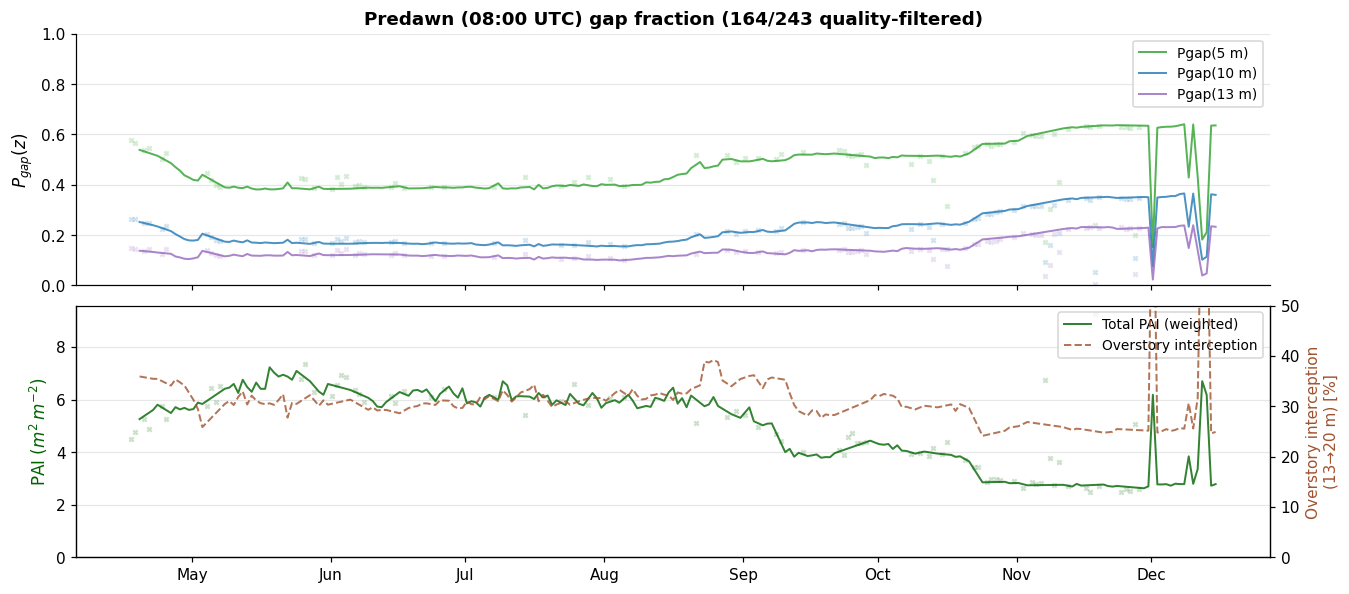

In [108]:
# Separate good and bad quality
good = df_predawn['quality_good']
df_good = df_predawn[good]
df_bad = df_predawn[~good]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                          gridspec_kw={'hspace': 0.08})

# Top: Pgap at understory heights
ax = axes[0]
for z, color, label in [(5, '#2ca02c', '5 m'), (10, '#1f77b4', '10 m'),
                          (13, '#9467bd', '13 m')]:
    col = f'pgap_{z}m'
    ax.plot(df_good.index, df_good[col], lw=1.3, color=color,
            label=f'Pgap({label})', alpha=0.8)
    ax.scatter(df_bad.index, df_bad[col], s=8, color=color,
              alpha=0.2, marker='x', zorder=1)
ax.set_ylabel(r'$P_{gap}(z)$', fontsize=11)
ax.set_ylim(0, 1)
ax.legend(fontsize=9, loc='upper right')
n_tot = len(df_predawn)
n_good = good.sum()
ax.set_title(f'Predawn ({PREDAWN_HOUR:02d}:00 UTC) gap fraction '
             f'({n_good}/{n_tot} quality-filtered)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)

# Bottom: total PAI + overstory interception
ax = axes[1]
ax.plot(df_good.index, df_good['pai_total'], lw=1.3, color='darkgreen',
        label='Total PAI (weighted)', alpha=0.8)
ax.scatter(df_bad.index, df_bad['pai_total'], s=8, color='darkgreen',
          alpha=0.2, marker='x', zorder=1)
ax2 = ax.twinx()
ax2.plot(df_good.index, df_good['overstory_interception'] * 100,
         lw=1.3, color='sienna', ls='--', label='Overstory interception', alpha=0.8)
ax.set_ylabel(r'PAI ($m^2\,m^{-2}$)', fontsize=11, color='darkgreen')
ax2.set_ylabel('Overstory interception\n(13→20 m) [%]', fontsize=10, color='sienna')
ax.set_ylim(bottom=0)
ax2.set_ylim(0, 50)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)
for spine in ('top',):
    ax.spines[spine].set_visible(False)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
fig.autofmt_xdate(rotation=0, ha='center')
plt.tight_layout()
plt.show()

---
## Figure 2: Cumulative PAI profiles (monthly snapshots)

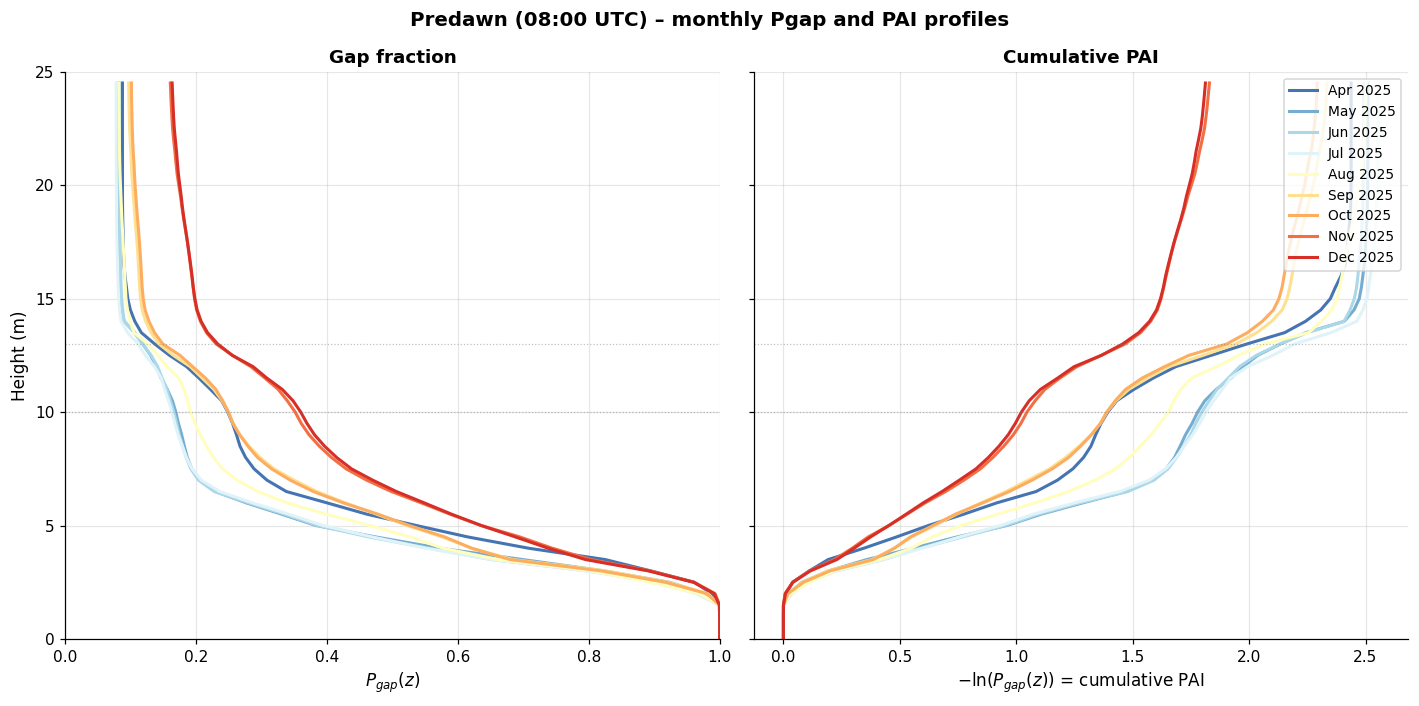

In [109]:
# Select one predawn scan per month (closest to 20th)
monthly_scans = {}
for r in predawn_results:
    dt = r['datetime']
    key = (dt.year, dt.month)
    if key not in monthly_scans:
        monthly_scans[key] = r
    else:
        # Pick closest to 20th of month
        if abs(dt.day - 20) < abs(monthly_scans[key]['datetime'].day - 20):
            monthly_scans[key] = r

months_sorted = sorted(monthly_scans.keys())
n = len(months_sorted)
colors = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, n))

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharey=True)

for i, key in enumerate(months_sorted):
    r = monthly_scans[key]
    h = r['height_bin']
    pgap = r['pgap_z']
    pai_cum = np.where(pgap > 0, -np.log(pgap), np.nan)
    label = r['datetime'].strftime('%b %Y')
    
    axes[0].plot(pgap, h, color=colors[i], lw=2, label=label)
    axes[1].plot(pai_cum, h, color=colors[i], lw=2, label=label)

for ax, xlabel, title in [
    (axes[0], r'$P_{gap}(z)$', 'Gap fraction'),
    (axes[1], r'$-\ln(P_{gap}(z))$ = cumulative PAI', 'Cumulative PAI')]:
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axhline(10, color='grey', ls=':', lw=0.8, alpha=0.5)
    ax.axhline(13, color='grey', ls=':', lw=0.8, alpha=0.5)
    ax.grid(alpha=0.3)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel('Height (m)', fontsize=11)
axes[0].set_ylim(0, MAX_H)
axes[0].set_xlim(0, 1)
axes[1].legend(loc='upper right', fontsize=9)

plt.suptitle(f'Predawn ({PREDAWN_HOUR:02d}:00 UTC) – monthly Pgap and PAI profiles',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Figure 3: Diurnal Pgap amplitude

Difference between afternoon and predawn Pgap on the same day.

- **Positive amplitude** at a given height → canopy more transparent in the afternoon (leaves wilting, curling → more gaps)
- **Increasing amplitude** over time → progressive loss of turgor recovery capacity
- **Amplitude collapse** → either leaves are gone (permanent structural loss) or stress is so severe that there's no diurnal variation left

In [110]:
# Match predawn and afternoon scans by date — quality-filtered only
df_pre_daily = df_predawn[df_predawn['quality_good']].copy()
df_pre_daily['date'] = df_pre_daily.index.date
df_aft_daily = df_afternoon[df_afternoon['quality_good']].copy()
df_aft_daily['date'] = df_aft_daily.index.date

# Merge on date (only days where BOTH predawn and afternoon pass quality)
df_diurnal = df_pre_daily.merge(df_aft_daily, on='date', suffixes=('_pre', '_aft'))
df_diurnal.index = pd.to_datetime(df_diurnal['date'])
df_diurnal = df_diurnal.sort_index()

print(f'Matched quality-filtered predawn-afternoon pairs: {len(df_diurnal)}')

# Compute amplitude: afternoon - predawn
# Positive = more transparent in afternoon = wilting
for z in Z_LEVELS:
    df_diurnal[f'delta_pgap_{z}m'] = (df_diurnal[f'pgap_{z}m_aft'] -
                                       df_diurnal[f'pgap_{z}m_pre'])

df_diurnal['delta_pai'] = df_diurnal['pai_total_pre'] - df_diurnal['pai_total_aft']

Matched quality-filtered predawn-afternoon pairs: 145


/tmp/ipykernel_1150964/2125730229.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


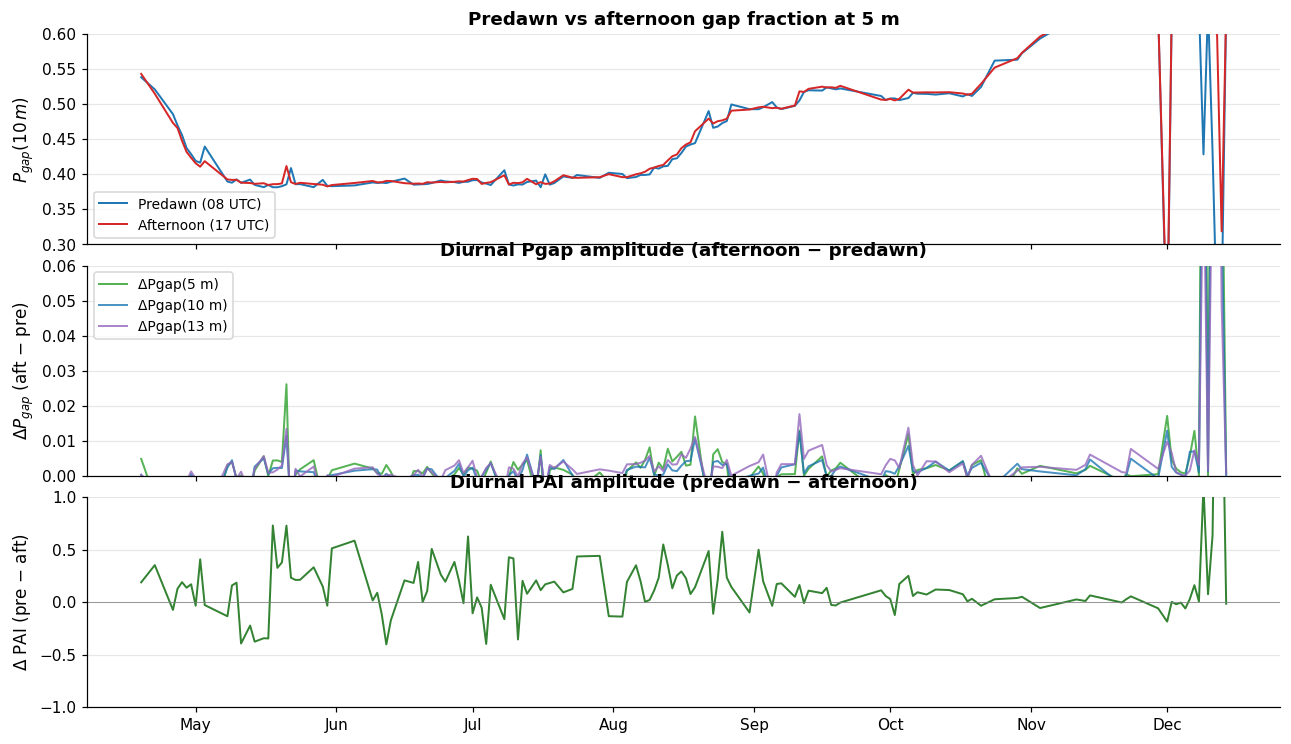

In [111]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True,
                          gridspec_kw={'hspace': 0.1})

# Top: Predawn vs afternoon Pgap at 10m
ax = axes[0]
ax.plot(df_diurnal.index, df_diurnal['pgap_5m_pre'], lw=1.3,
        color='#1f77b4', label=f'Predawn ({PREDAWN_HOUR:02d} UTC)')
ax.plot(df_diurnal.index, df_diurnal['pgap_5m_aft'], lw=1.3,
        color='#d62728', label=f'Afternoon ({AFTERNOON_HOUR:02d} UTC)')
ax.set_ylabel(r'$P_{gap}(10\,m)$', fontsize=11)
ax.set_title('Predawn vs afternoon gap fraction at 5 m', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.3, 0.6)

# Middle: Diurnal amplitude at multiple heights
ax = axes[1]
for z, color in zip([5, 10, 13], ['#2ca02c', '#1f77b4', '#9467bd']):
    ax.plot(df_diurnal.index, df_diurnal[f'delta_pgap_{z}m'],
            lw=1.3, color=color, label=f'ΔPgap({z} m)', alpha=0.8)
ax.axhline(0, color='grey', ls='-', lw=0.5)
ax.set_ylabel(r'$\Delta P_{gap}$ (aft − pre)', fontsize=11)
ax.set_title('Diurnal Pgap amplitude (afternoon − predawn)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 0.06)

# Bottom: Diurnal PAI amplitude
ax = axes[2]
ax.plot(df_diurnal.index, df_diurnal['delta_pai'], lw=1.3,
        color='darkgreen', alpha=0.8)
ax.axhline(0, color='grey', ls='-', lw=0.5)
ax.set_ylabel(r'$\Delta$ PAI (pre − aft)', fontsize=11)
ax.set_title('Diurnal PAI amplitude (predawn − afternoon)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-1, 1)

for ax in axes:
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
fig.autofmt_xdate(rotation=0, ha='center')
plt.tight_layout()
plt.show()

---
## Export for SPAC cascade integration

In [112]:
# Predawn time series — main product for PELT and VOD correction
# All scans included; use quality_good column to filter downstream
df_predawn.to_csv('leaf_predawn_pgap_timeseries.csv')

# Quality-filtered predawn only
df_predawn[df_predawn['quality_good']].to_csv('leaf_predawn_pgap_filtered.csv')

# Diurnal amplitude — stress indicator (already quality-filtered)
export_cols = ['date',
               'pgap_10m_pre', 'pgap_10m_aft', 'delta_pgap_10m',
               'pgap_5m_pre', 'pgap_5m_aft', 'delta_pgap_5m',
               'pai_total_pre', 'pai_total_aft', 'delta_pai',
               'vpd_mean_pre', 'vpd_mean_aft',
               'tair_mean_pre', 'tair_mean_aft']
# Keep only columns that exist
export_cols = [c for c in export_cols if c in df_diurnal.columns]
df_diurnal[export_cols].to_csv('leaf_diurnal_amplitude.csv', index=False)

print('Exported:')
print(f'  leaf_predawn_pgap_timeseries.csv  ({len(df_predawn)} rows, all scans)')
print(f'  leaf_predawn_pgap_filtered.csv    ({df_predawn.quality_good.sum()} rows, quality only)')
print(f'  leaf_diurnal_amplitude.csv        ({len(df_diurnal)} rows, quality pairs)')

Exported:
  leaf_predawn_pgap_timeseries.csv  (243 rows, all scans)
  leaf_predawn_pgap_filtered.csv    (164 rows, quality only)
  leaf_diurnal_amplitude.csv        (145 rows, quality pairs)


---
## Summary figures

Visual synthesis of the key findings from the Pgap / PAI diurnal analysis.

/tmp/ipykernel_1150964/3551797022.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


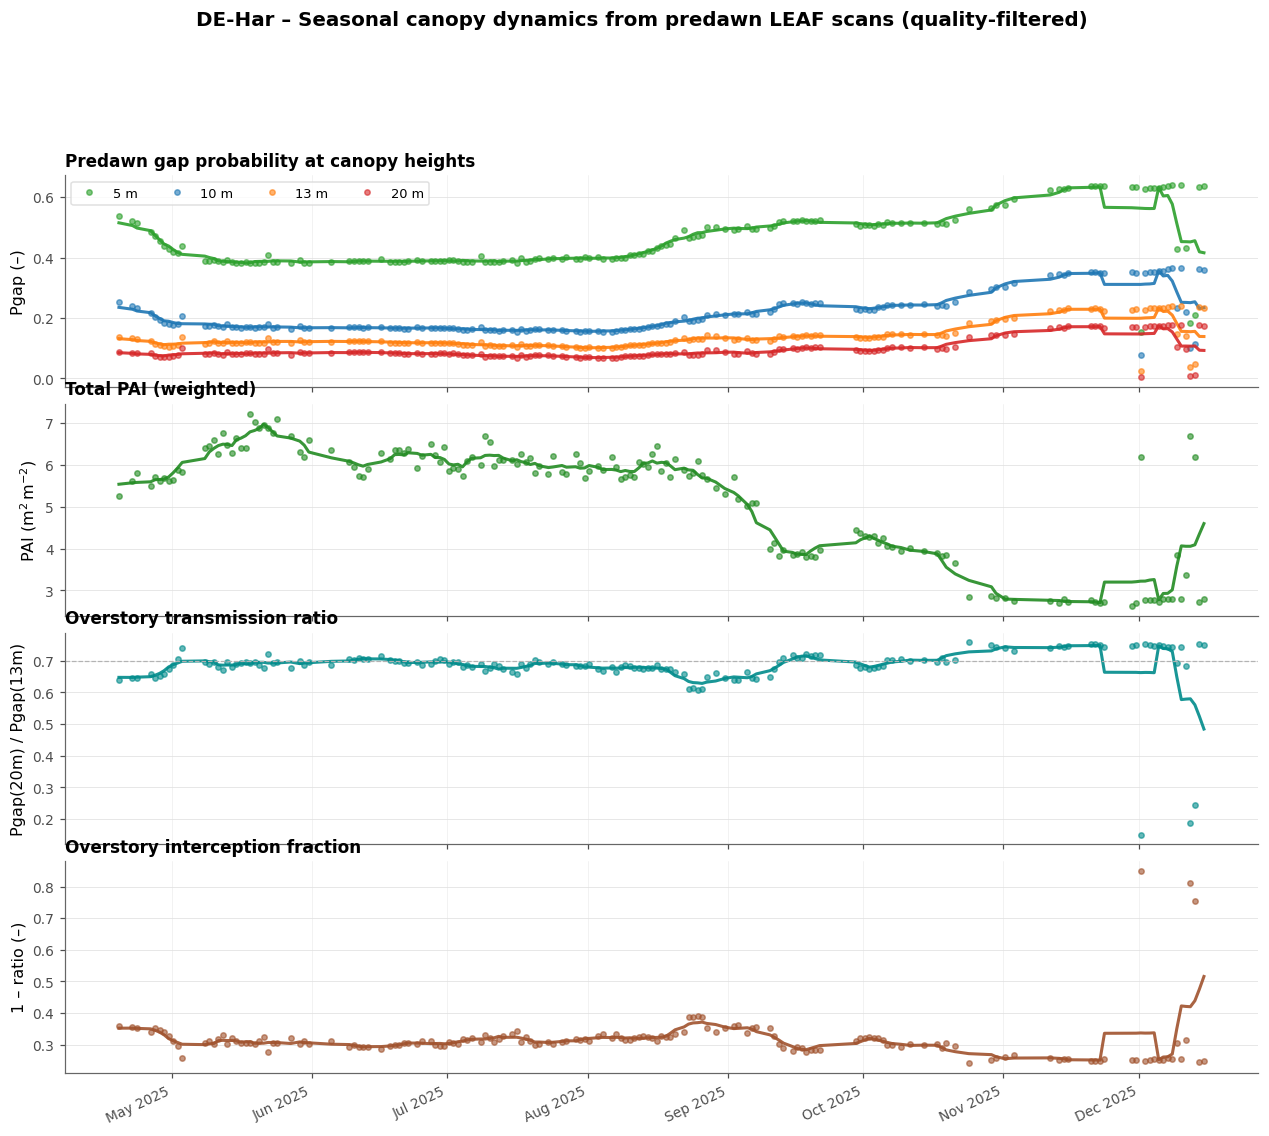

In [113]:
# ── Fig S1: Seasonal overview — Pgap, PAI, overstory ratio ──────────
df = df_predawn[df_predawn['quality_good']].copy()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True,
                          gridspec_kw={'hspace': 0.08})
fig.patch.set_facecolor('white')

style = dict(lw=0, marker='o', ms=3.5, alpha=0.6)
smooth_kw = dict(window=7, center=True, min_periods=3)

# Panel 1: Pgap at multiple heights
ax = axes[0]
ax.set_facecolor('white')
colors_pgap = {'5': '#2ca02c', '10': '#1f77b4', '13': '#ff7f0e', '20': '#d62728'}
for z in Z_LEVELS:
    c = colors_pgap[str(z)]
    ax.plot(df.index, df[f'pgap_{z}m'], color=c, label=f'{z} m', **style)
    ax.plot(df.index, df[f'pgap_{z}m'].rolling(**smooth_kw).mean(),
            color=c, lw=2, alpha=0.9)
ax.set_ylabel('Pgap (–)', fontsize=10.5)
ax.set_title('Predawn gap probability at canopy heights', fontsize=11,
             fontweight='bold', loc='left', pad=6)
ax.legend(fontsize=8.5, ncol=4, loc='upper left', frameon=True,
          edgecolor='0.85', fancybox=True)

# Panel 2: Total PAI
ax = axes[1]
ax.set_facecolor('white')
ax.plot(df.index, df['pai_total'], color='forestgreen', **style)
ax.plot(df.index, df['pai_total'].rolling(**smooth_kw).mean(),
        color='forestgreen', lw=2, alpha=0.9)
ax.set_ylabel(r'PAI ($\mathregular{m^2\,m^{-2}}$)', fontsize=10.5)
ax.set_title('Total PAI (weighted)', fontsize=11,
             fontweight='bold', loc='left', pad=6)

# Panel 3: Overstory ratio
ax = axes[2]
ax.set_facecolor('white')
ax.plot(df.index, df['overstory_ratio'], color='darkcyan', **style)
ax.plot(df.index, df['overstory_ratio'].rolling(**smooth_kw).mean(),
        color='darkcyan', lw=2, alpha=0.9)
ax.set_ylabel('Pgap(20m) / Pgap(13m)', fontsize=10.5)
ax.set_title('Overstory transmission ratio', fontsize=11,
             fontweight='bold', loc='left', pad=6)
ax.axhline(0.70, color='0.7', ls='--', lw=0.8)

# Panel 4: Overstory interception
ax = axes[3]
ax.set_facecolor('white')
ax.plot(df.index, 1 - df['overstory_ratio'], color='sienna', **style)
ax.plot(df.index, (1 - df['overstory_ratio']).rolling(**smooth_kw).mean(),
        color='sienna', lw=2, alpha=0.9)
ax.set_ylabel('1 – ratio (–)', fontsize=10.5)
ax.set_title('Overstory interception fraction', fontsize=11,
             fontweight='bold', loc='left', pad=6)

for ax in axes:
    ax.grid(axis='y', color='0.88', lw=0.5)
    ax.grid(axis='x', color='0.92', lw=0.4)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color('0.4')
    ax.spines['bottom'].set_color('0.4')
    ax.tick_params(colors='0.3', labelsize=9)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate(rotation=25, ha='right')
fig.suptitle('DE-Har – Seasonal canopy dynamics from predawn LEAF scans (quality-filtered)',
             fontsize=13, fontweight='bold', y=1.005)
fig.tight_layout()
plt.show()

/tmp/ipykernel_1150964/2720784825.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


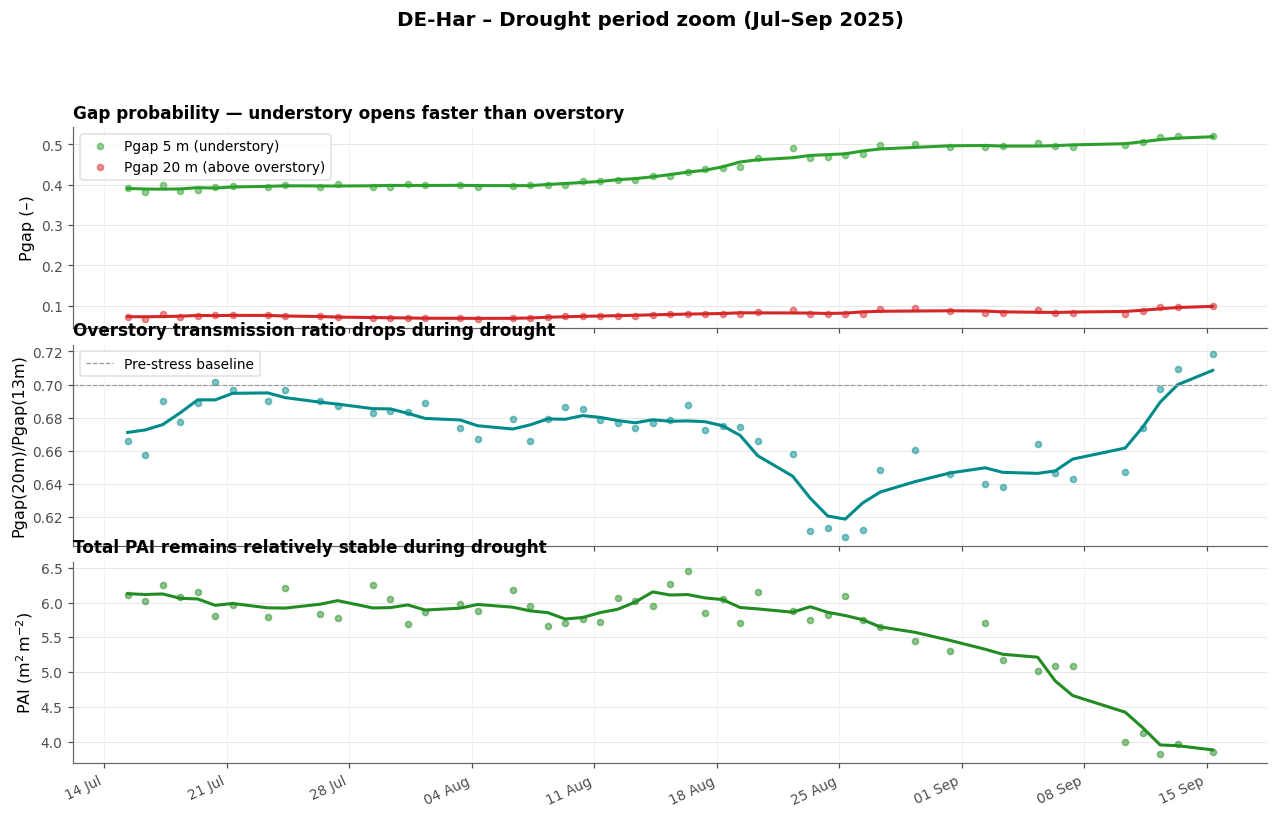

In [114]:
# ── Fig S2: Drought zoom — understory vs overstory Pgap divergence ──
drought_start = '2025-07-15'
drought_end = '2025-09-15'
df_zoom = df.loc[drought_start:drought_end]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 8.5), sharex=True,
                                      gridspec_kw={'hspace': 0.08})
fig.patch.set_facecolor('white')

# Pgap at understory (5m) and overstory (20m)
for z, c, lab in [(5, '#2ca02c', 'Pgap 5 m (understory)'),
                   (20, '#d62728', 'Pgap 20 m (above overstory)')]:
    ax1.plot(df_zoom.index, df_zoom[f'pgap_{z}m'], 'o', ms=4, color=c,
             alpha=0.5, label=lab)
    ax1.plot(df_zoom.index, df_zoom[f'pgap_{z}m'].rolling(5, center=True, min_periods=2).mean(),
             color=c, lw=2)
ax1.set_ylabel('Pgap (–)', fontsize=10.5)
ax1.set_title('Gap probability — understory opens faster than overstory',
              fontsize=11, fontweight='bold', loc='left', pad=6)
ax1.legend(fontsize=9, frameon=True, edgecolor='0.85', fancybox=True)

# Overstory ratio
ax2.plot(df_zoom.index, df_zoom['overstory_ratio'], 'o', ms=4,
         color='darkcyan', alpha=0.5)
ax2.plot(df_zoom.index, df_zoom['overstory_ratio'].rolling(5, center=True, min_periods=2).mean(),
         color='darkcyan', lw=2)
ax2.axhline(0.70, color='0.6', ls='--', lw=0.8, label='Pre-stress baseline')
ax2.set_ylabel('Pgap(20m)/Pgap(13m)', fontsize=10.5)
ax2.set_title('Overstory transmission ratio drops during drought',
              fontsize=11, fontweight='bold', loc='left', pad=6)
ax2.legend(fontsize=9, frameon=True, edgecolor='0.85', fancybox=True)

# PAI
ax3.plot(df_zoom.index, df_zoom['pai_total'], 'o', ms=4,
         color='forestgreen', alpha=0.5)
ax3.plot(df_zoom.index, df_zoom['pai_total'].rolling(5, center=True, min_periods=2).mean(),
         color='forestgreen', lw=2)
ax3.set_ylabel(r'PAI ($\mathregular{m^2\,m^{-2}}$)', fontsize=10.5)
ax3.set_title('Total PAI remains relatively stable during drought',
              fontsize=11, fontweight='bold', loc='left', pad=6)

for ax in (ax1, ax2, ax3):
    ax.set_facecolor('white')
    ax.grid(axis='y', color='0.88', lw=0.5)
    ax.grid(axis='x', color='0.92', lw=0.4)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color('0.4')
    ax.spines['bottom'].set_color('0.4')
    ax.tick_params(colors='0.3', labelsize=9)

ax3.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax3.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
fig.autofmt_xdate(rotation=25, ha='right')
fig.suptitle('DE-Har – Drought period zoom (Jul–Sep 2025)',
             fontsize=13, fontweight='bold', y=1.005)
fig.tight_layout()
plt.show()

/tmp/ipykernel_1150964/355658688.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


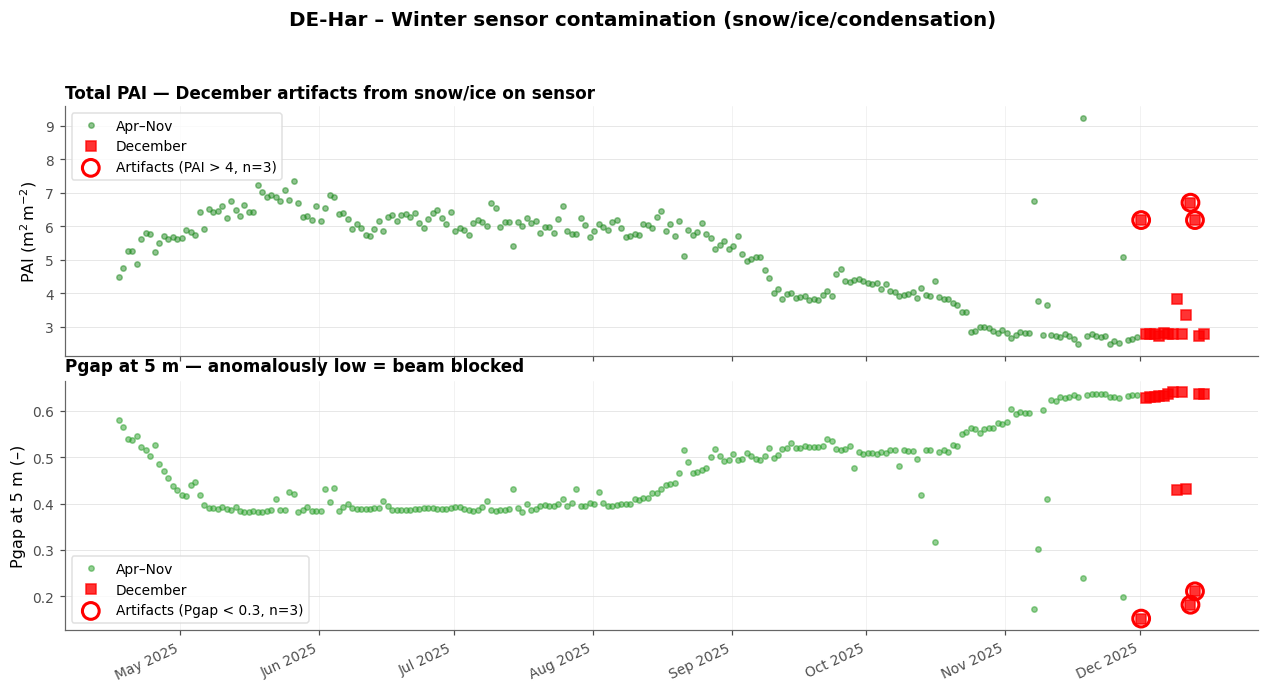

In [115]:
# ── Fig S3: December sensor artifacts — snow/ice contamination ──────
df_all = df_predawn.copy()
dec_mask = df_all.index.month == 12

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                 gridspec_kw={'hspace': 0.1})
fig.patch.set_facecolor('white')

# PAI — flag outliers
ax1.set_facecolor('white')
ax1.plot(df_all.index[~dec_mask], df_all.loc[~dec_mask, 'pai_total'],
         'o', ms=3.5, color='forestgreen', alpha=0.5, label='Apr–Nov')
ax1.plot(df_all.index[dec_mask], df_all.loc[dec_mask, 'pai_total'],
         's', ms=6, color='red', alpha=0.8, zorder=5, label='December')

# Highlight the anomalous December entries
dec_bad = df_all[dec_mask & (df_all['pai_total'] > 4.0)]
if len(dec_bad):
    ax1.scatter(dec_bad.index, dec_bad['pai_total'], s=120,
                facecolors='none', edgecolors='red', lw=2, zorder=6,
                label=f'Artifacts (PAI > 4, n={len(dec_bad)})')
ax1.set_ylabel(r'PAI ($\mathregular{m^2\,m^{-2}}$)', fontsize=10.5)
ax1.set_title('Total PAI — December artifacts from snow/ice on sensor',
              fontsize=11, fontweight='bold', loc='left', pad=6)
ax1.legend(fontsize=9, frameon=True, edgecolor='0.85', fancybox=True)

# Pgap at 5m
ax2.set_facecolor('white')
ax2.plot(df_all.index[~dec_mask], df_all.loc[~dec_mask, 'pgap_5m'],
         'o', ms=3.5, color='#2ca02c', alpha=0.5, label='Apr–Nov')
ax2.plot(df_all.index[dec_mask], df_all.loc[dec_mask, 'pgap_5m'],
         's', ms=6, color='red', alpha=0.8, zorder=5, label='December')

dec_bad_pgap = df_all[dec_mask & (df_all['pgap_5m'] < 0.3)]
if len(dec_bad_pgap):
    ax2.scatter(dec_bad_pgap.index, dec_bad_pgap['pgap_5m'], s=120,
                facecolors='none', edgecolors='red', lw=2, zorder=6,
                label=f'Artifacts (Pgap < 0.3, n={len(dec_bad_pgap)})')
ax2.set_ylabel('Pgap at 5 m (–)', fontsize=10.5)
ax2.set_title('Pgap at 5 m — anomalously low = beam blocked',
              fontsize=11, fontweight='bold', loc='left', pad=6)
ax2.legend(fontsize=9, frameon=True, edgecolor='0.85', fancybox=True)

for ax in (ax1, ax2):
    ax.grid(axis='y', color='0.88', lw=0.5)
    ax.grid(axis='x', color='0.92', lw=0.4)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color('0.4')
    ax.spines['bottom'].set_color('0.4')
    ax.tick_params(colors='0.3', labelsize=9)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate(rotation=25, ha='right')
fig.suptitle('DE-Har – Winter sensor contamination (snow/ice/condensation)',
             fontsize=13, fontweight='bold', y=1.005)
fig.tight_layout()
plt.show()

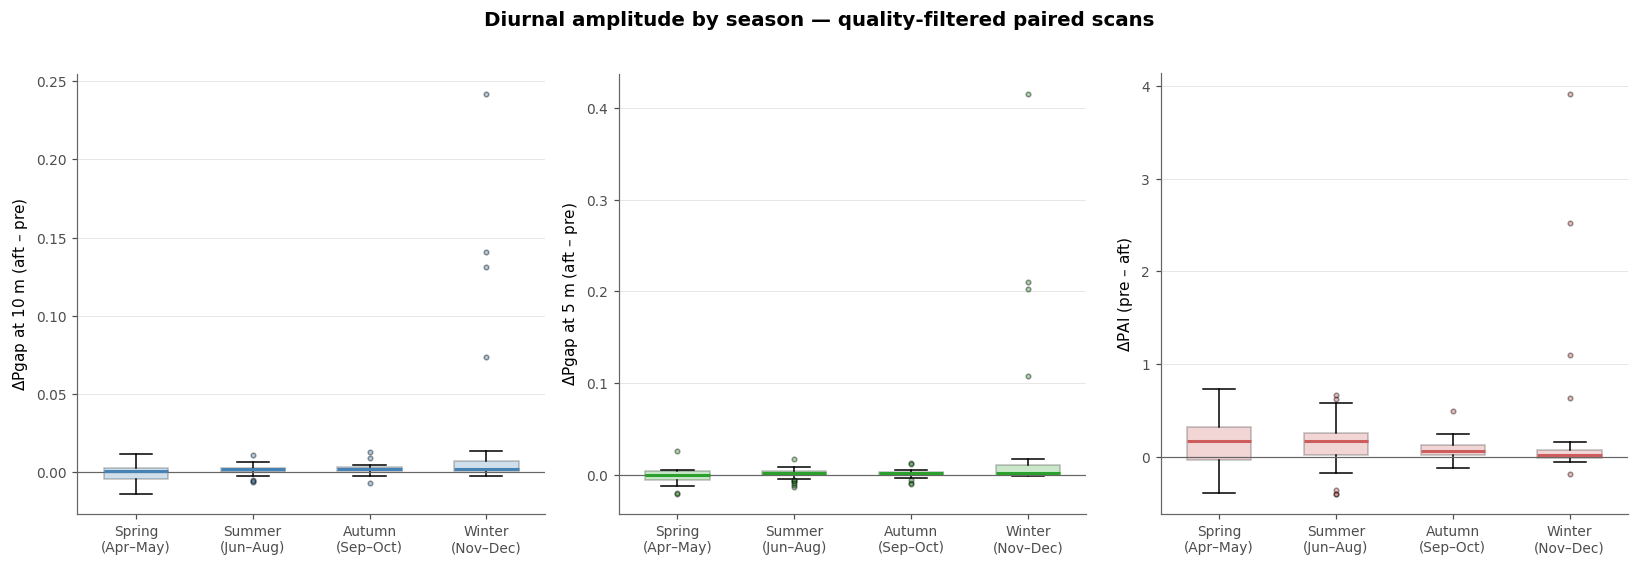

Seasonal mean ± std of diurnal amplitude:

  $\Delta$Pgap at 10 m (aft – pre):
    Spring (Apr–May): -0.0013 ± 0.0054  (n=29)
    Summer (Jun–Aug): +0.0012 ± 0.0028  (n=62)
    Autumn (Sep–Oct): +0.0020 ± 0.0032  (n=32)
    Winter (Nov–Dec): +0.0286 ± 0.0631  (n=22)

  $\Delta$Pgap at 5 m (aft – pre):
    Spring (Apr–May): -0.0013 ± 0.0086  (n=29)
    Summer (Jun–Aug): +0.0014 ± 0.0047  (n=62)
    Autumn (Sep–Oct): +0.0013 ± 0.0044  (n=32)
    Winter (Nov–Dec): +0.0449 ± 0.1037  (n=22)

  $\Delta$PAI (pre – aft):
    Spring (Apr–May): +0.1286 ± 0.2962  (n=29)
    Summer (Jun–Aug): +0.1556 ± 0.2340  (n=62)
    Autumn (Sep–Oct): +0.0824 ± 0.1112  (n=32)
    Winter (Nov–Dec): +0.3740 ± 0.9840  (n=22)


In [116]:
# ── Fig S4: Diurnal amplitude — seasonal distribution ───────────────
# Bin into seasons
df_d = df_diurnal.copy()
month = df_d.index.month
seasons = pd.cut(month, bins=[0, 5, 8, 10, 12],
                 labels=['Spring\n(Apr–May)', 'Summer\n(Jun–Aug)',
                         'Autumn\n(Sep–Oct)', 'Winter\n(Nov–Dec)'])
df_d['season'] = seasons

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('white')

metrics = [
    ('delta_pgap_10m', r'$\Delta$Pgap at 10 m (aft – pre)', 'steelblue'),
    ('delta_pgap_5m',  r'$\Delta$Pgap at 5 m (aft – pre)',  '#2ca02c'),
    ('delta_pai',      r'$\Delta$PAI (pre – aft)',           'indianred'),
]

for ax, (col, ylabel, color) in zip(axes, metrics):
    ax.set_facecolor('white')
    season_order = ['Spring\n(Apr–May)', 'Summer\n(Jun–Aug)',
                    'Autumn\n(Sep–Oct)', 'Winter\n(Nov–Dec)']
    positions = []
    labels_used = []
    for i, s in enumerate(season_order):
        vals = df_d.loc[df_d['season'] == s, col].dropna()
        if len(vals) == 0:
            continue
        bp = ax.boxplot([vals], positions=[i], widths=0.55,
                        patch_artist=True, showfliers=True,
                        flierprops=dict(marker='o', ms=3, alpha=0.4,
                                        markerfacecolor=color))
        bp['boxes'][0].set_facecolor(color)
        bp['boxes'][0].set_alpha(0.25)
        bp['medians'][0].set_color(color)
        bp['medians'][0].set_linewidth(2)
        positions.append(i)
        labels_used.append(s)

    ax.axhline(0, color='0.4', ls='-', lw=0.8)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels_used, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(axis='y', color='0.88', lw=0.5)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color('0.4')
    ax.spines['bottom'].set_color('0.4')
    ax.tick_params(colors='0.3', labelsize=9)

fig.suptitle('Diurnal amplitude by season — quality-filtered paired scans',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

# Print summary statistics
print('Seasonal mean ± std of diurnal amplitude:')
for col, label, _ in metrics:
    print(f'\n  {label}:')
    for s in season_order:
        vals = df_d.loc[df_d['season'] == s, col].dropna()
        if len(vals):
            print(f'    {s.replace(chr(10), " ")}: '
                  f'{vals.mean():+.4f} ± {vals.std():.4f}  (n={len(vals)})')

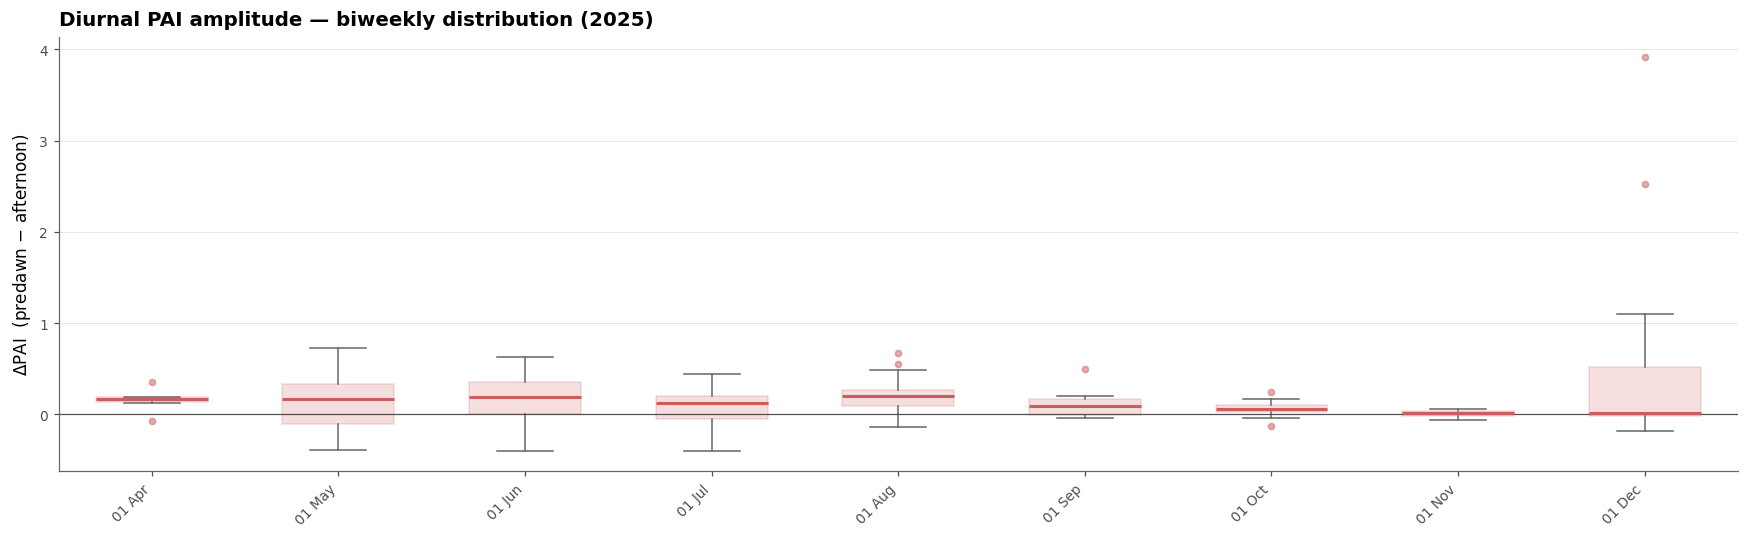

Period         n     mean   median      std
---------------------------------------------
01 Apr         7  +0.1556  +0.1697  0.1164
01 May        22  +0.1201  +0.1718  0.3272
01 Jun        18  +0.1685  +0.1884  0.2598
01 Jul        21  +0.0992  +0.1257  0.2318
01 Aug        23  +0.1969  +0.1986  0.1965
01 Sep        16  +0.1033  +0.0971  0.1285
01 Oct        16  +0.0616  +0.0548  0.0811
01 Nov         8  +0.0080  +0.0180  0.0429
01 Dec        14  +0.5831  +0.0182  1.1537


In [117]:
# ── Fig S5: ΔPA biweekly boxplots across 2025 ─────────────────────
df_d2 = df_diurnal[['delta_pai']].copy()
df_d2 = df_d2.loc['2025']

# Biweekly period labels
period = df_d2.index.to_period('1M')
df_d2['period'] = period
df_d2['period_start'] = period.start_time

groups = df_d2.groupby('period')
period_labels = []
period_data = []
period_positions = []
for i, (p, grp) in enumerate(groups):
    vals = grp['delta_pai'].dropna()
    if len(vals) < 2:
        continue
    period_data.append(vals.values)
    period_labels.append(p.start_time.strftime('%d %b'))
    period_positions.append(i)

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bp = ax.boxplot(period_data, positions=period_positions, widths=0.6,
                patch_artist=True, showfliers=True,
                flierprops=dict(marker='o', ms=4, alpha=0.5,
                                markerfacecolor='indianred',
                                markeredgecolor='indianred'))

for box in bp['boxes']:
    box.set_facecolor('indianred')
    box.set_alpha(0.2)
    box.set_edgecolor('indianred')
for med in bp['medians']:
    med.set_color('indianred')
    med.set_linewidth(2)
for w in bp['whiskers'] + bp['caps']:
    w.set_color('0.4')

ax.axhline(0, color='0.3', ls='-', lw=0.8)
ax.set_xticks(period_positions)
ax.set_xticklabels(period_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel(r'$\Delta$PAI  (predawn $-$ afternoon)', fontsize=11)
ax.set_title('Diurnal PAI amplitude — biweekly distribution (2025)',
             fontsize=13, fontweight='bold', loc='left', pad=8)

ax.grid(axis='y', color='0.88', lw=0.5)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_color('0.4')
ax.spines['bottom'].set_color('0.4')
ax.tick_params(colors='0.3', labelsize=9)

fig.tight_layout()
plt.show()

# Summary table
print(f'{"Period":<12} {"n":>3}  {"mean":>7}  {"median":>7}  {"std":>7}')
print('-' * 45)
for pos, lbl, vals in zip(period_positions, period_labels, period_data):
    v = np.array(vals)
    print(f'{lbl:<12} {len(v):>3}  {v.mean():+.4f}  {np.median(v):+.4f}  {v.std():.4f}')

Height-band diurnal pairs (2025): 145


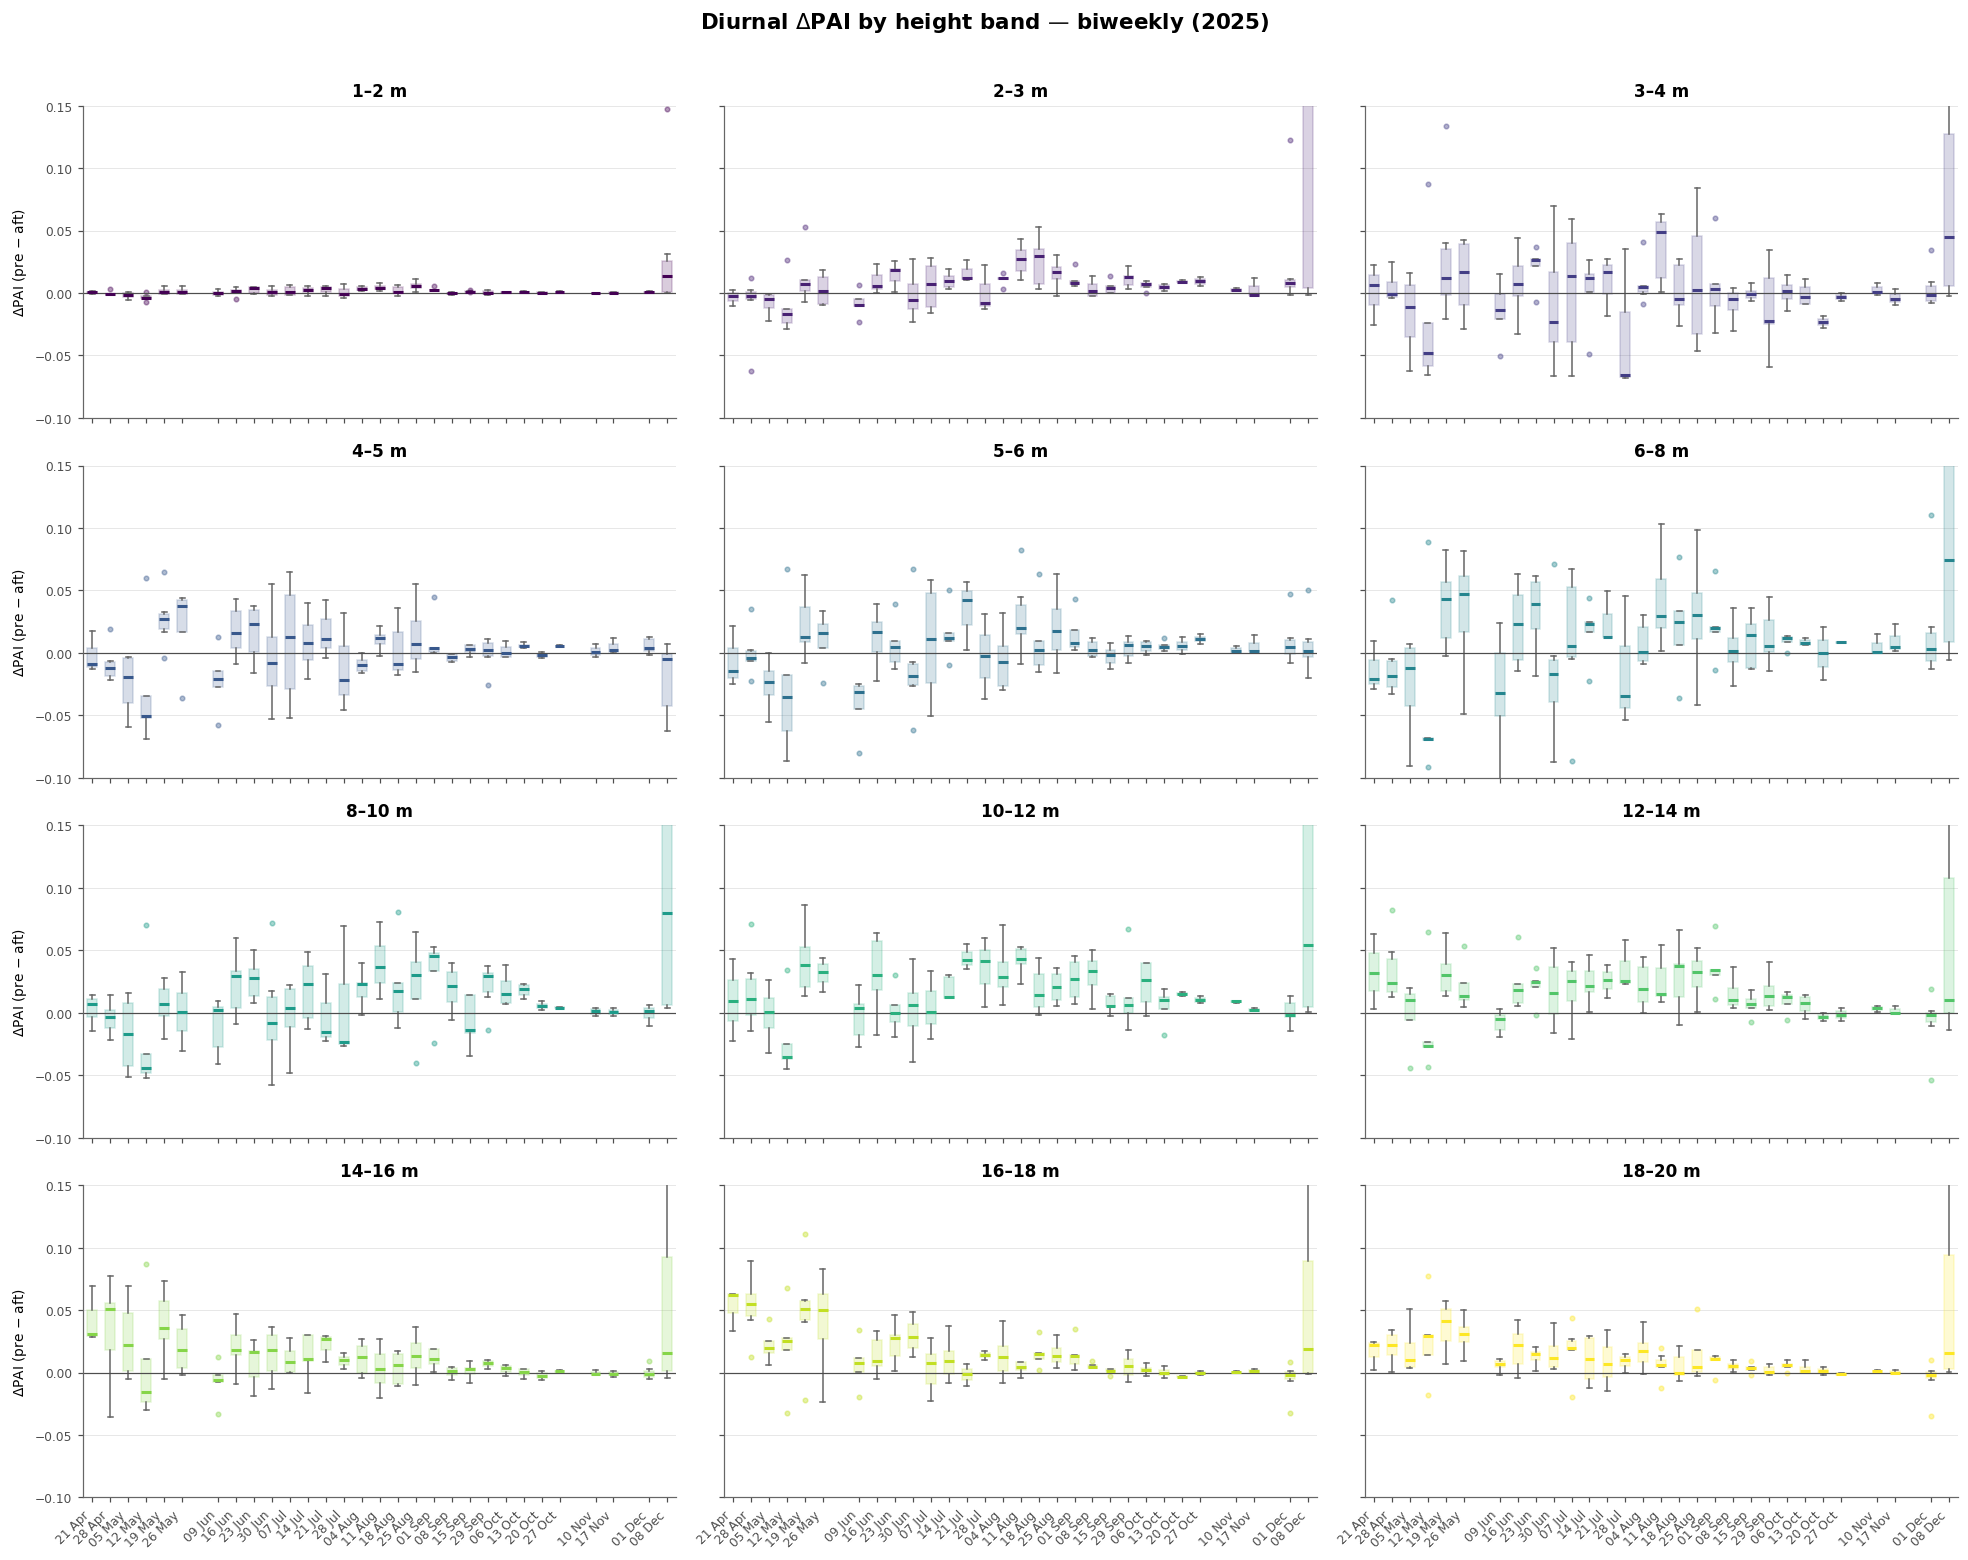

In [120]:
# ── Fig S6: Biweekly ΔPAI by height band (2025) ───────────────────
HEIGHT_BANDS = [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 8), (8, 10), (10, 12),
                (12, 14), (14, 16), (16, 18), (18, 20)]

def _band_pai(result, bands):
    """Extract PAI per height band from a cumulative pai_weighted profile."""
    h = result['height_bin']
    pai_cum = result['pai_weighted']
    out = {}
    for lo, hi in bands:
        idx_lo = np.argmin(np.abs(h - lo))
        idx_hi = np.argmin(np.abs(h - hi))
        out[(lo, hi)] = pai_cum[idx_hi] - pai_cum[idx_lo]
    return out

def _results_to_band_df(results, bands):
    rows = []
    for r in results:
        qf = r.get('qf', {})
        if not qf.get('good', True):
            continue
        row = {'datetime': r['datetime']}
        bpai = _band_pai(r, bands)
        for (lo, hi), val in bpai.items():
            row[f'pai_{lo}_{hi}'] = val
        rows.append(row)
    df = pd.DataFrame(rows).set_index('datetime').sort_index()
    df.index = pd.to_datetime(df.index)
    return df

df_pre_bands = _results_to_band_df(predawn_results, HEIGHT_BANDS)
df_aft_bands = _results_to_band_df(afternoon_results, HEIGHT_BANDS)

df_pre_bands['date'] = df_pre_bands.index.date
df_aft_bands['date'] = df_aft_bands.index.date

df_bands = df_pre_bands.merge(df_aft_bands, on='date', suffixes=('_pre', '_aft'))
df_bands.index = pd.to_datetime(df_bands['date'])
df_bands = df_bands.loc['2025'].sort_index()

for lo, hi in HEIGHT_BANDS:
    col = f'pai_{lo}_{hi}'
    df_bands[f'delta_{col}'] = df_bands[f'{col}_pre'] - df_bands[f'{col}_aft']

print(f'Height-band diurnal pairs (2025): {len(df_bands)}')

# Biweekly grouping
period = df_bands.index.to_period('2W')
df_bands['period'] = period

# --- Multi-panel plot ---
ncols, nrows = 3, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 14), sharex=True, sharey=True)
fig.patch.set_facecolor('white')

cmap = plt.cm.viridis
norm = plt.Normalize(0, len(HEIGHT_BANDS) - 1)

for idx, (lo, hi) in enumerate(HEIGHT_BANDS):
    ax = axes.flat[idx]
    ax.set_facecolor('white')
    col = f'delta_pai_{lo}_{hi}'
    color = cmap(norm(idx))

    groups = df_bands.groupby('period')
    positions, labels, data = [], [], []
    for i, (p, grp) in enumerate(groups):
        vals = grp[col].dropna()
        if len(vals) < 2:
            continue
        data.append(vals.values)
        labels.append(p.start_time.strftime('%d %b'))
        positions.append(i)

    if data:
        bp = ax.boxplot(data, positions=positions, widths=0.55,
                        patch_artist=True, showfliers=True,
                        flierprops=dict(marker='o', ms=3, alpha=0.4,
                                        markerfacecolor=color,
                                        markeredgecolor=color))
        for box in bp['boxes']:
            box.set_facecolor(color)
            box.set_alpha(0.2)
            box.set_edgecolor(color)
        for med in bp['medians']:
            med.set_color(color)
            med.set_linewidth(2)
        for w in bp['whiskers'] + bp['caps']:
            w.set_color('0.4')

    ax.axhline(0, color='0.3', ls='-', lw=0.8)
    ax.set_title(f'{lo}–{hi} m', fontsize=11, fontweight='bold')
    ax.grid(axis='y', color='0.88', lw=0.5)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color('0.4')
    ax.spines['bottom'].set_color('0.4')
    ax.tick_params(colors='0.3', labelsize=8)
    ax.set_ylim(-0.1, 0.15)

    if idx >= (nrows - 1) * ncols:
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)

for ax in axes[:, 0]:
    ax.set_ylabel(r'$\Delta$PAI (pre $-$ aft)', fontsize=9)

fig.suptitle(r'Diurnal $\Delta$PAI by height band — biweekly (2025)',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

---
## Full diurnal analysis — all 8 scan hours

Process every available scan hour (02, 05, 08, 11, 14, 17, 20, 23 UTC) to characterise the complete diurnal cycle of PAI and its height-resolved structure across 2025.

In [91]:
# ── Process ALL scan hours ──────────────────────────────────────────
from multiprocessing import Pool
import os

ALL_HOURS = sorted(hour_counts.keys())
print(f'Scan hours (UTC): {ALL_HOURS}')

files_by_hour = {}
for h in ALL_HOURS:
    files_by_hour[h] = sorted([f for f in hemi_hi_files if get_utc_hour(f) == h])
    print(f'  {h:02d}:00 → {len(files_by_hour[h])} files')

already_processed = {}
for r in predawn_results:
    already_processed[str(r['datetime'])] = r
for r in afternoon_results:
    already_processed[str(r['datetime'])] = r
print(f'\nAlready processed (predawn+afternoon): {len(already_processed)}')

files_to_process = []
for h in ALL_HOURS:
    if h in (PREDAWN_HOUR, AFTERNOON_HOUR):
        continue
    files_to_process.extend(files_by_hour[h])
print(f'New files to process: {len(files_to_process)}')

def _worker_all(filepath_str):
    from pathlib import Path
    r = process_scan(Path(filepath_str))
    return (filepath_str, r)

n_workers = min(32, os.cpu_count() or 4)
t0 = time.time()
file_strs = [str(f) for f in files_to_process]

new_results = []
with Pool(n_workers) as pool:
    for i, (fstr, r) in enumerate(pool.imap(_worker_all, file_strs, chunksize=16)):
        if r is not None:
            scan_dt = get_datetime(Path(fstr))
            r['qf'] = quality_flag_scan(scan_dt, met_full)
            new_results.append(r)
        if (i + 1) % 200 == 0 or (i + 1) == len(file_strs):
            elapsed = time.time() - t0
            print(f'  {i+1}/{len(file_strs)} ({elapsed:.0f}s)')

print(f'\nNew scans processed: {len(new_results)} in {time.time()-t0:.0f}s')

# Combine all results into one list
all_results = list(already_processed.values()) + new_results
print(f'Total results: {len(all_results)}')

# Build unified DataFrame with height-band PAI
DIURNAL_BANDS = [(0, 2), (2, 4), (4, 6), (6, 8), (8, 10),
                 (10, 12), (12, 14), (14, 16), (16, 18), (18, 20)]

rows = []
for r in all_results:
    qf = r.get('qf', {})
    if not qf.get('good', True):
        continue
    h_bins = r['height_bin']
    pai_cum = r['pai_weighted']
    row = {
        'datetime': r['datetime'],
        'pai_total': r['pai_total'],
    }
    for lo, hi in DIURNAL_BANDS:
        idx_lo = np.argmin(np.abs(h_bins - lo))
        idx_hi = np.argmin(np.abs(h_bins - hi))
        row[f'pai_{lo}_{hi}'] = pai_cum[idx_hi] - pai_cum[idx_lo]
    rows.append(row)

df_all = pd.DataFrame(rows)
df_all['datetime'] = pd.to_datetime(df_all['datetime'])
df_all['utc_hour'] = df_all['datetime'].dt.hour
df_all['date'] = df_all['datetime'].dt.date
df_all['month'] = df_all['datetime'].dt.month
df_all['month_name'] = df_all['datetime'].dt.strftime('%b')
df_all = df_all.sort_values('datetime').reset_index(drop=True)

print(f'\nQuality-filtered scans in df_all: {len(df_all)}')
print(f'By hour:')
for h in ALL_HOURS:
    n = (df_all['utc_hour'] == h).sum()
    print(f'  {h:02d}:00 → {n}')

Scan hours (UTC): [2, 5, 8, 11, 14, 17, 20, 23]
  02:00 → 243 files
  05:00 → 243 files
  08:00 → 243 files
  11:00 → 241 files
  14:00 → 242 files
  17:00 → 242 files
  20:00 → 243 files
  23:00 → 243 files

Already processed (predawn+afternoon): 486
New files to process: 1454
  200/1454 (7s)
  400/1454 (7s)
  600/1454 (13s)
  800/1454 (13s)
  1000/1454 (14s)
  1200/1454 (19s)
  1400/1454 (19s)
  1454/1454 (19s)

New scans processed: 1454 in 19s
Total results: 1940

Quality-filtered scans in df_all: 1273
By hour:
  02:00 → 170
  05:00 → 128
  08:00 → 133
  11:00 → 146
  14:00 → 140
  17:00 → 192
  20:00 → 188
  23:00 → 176


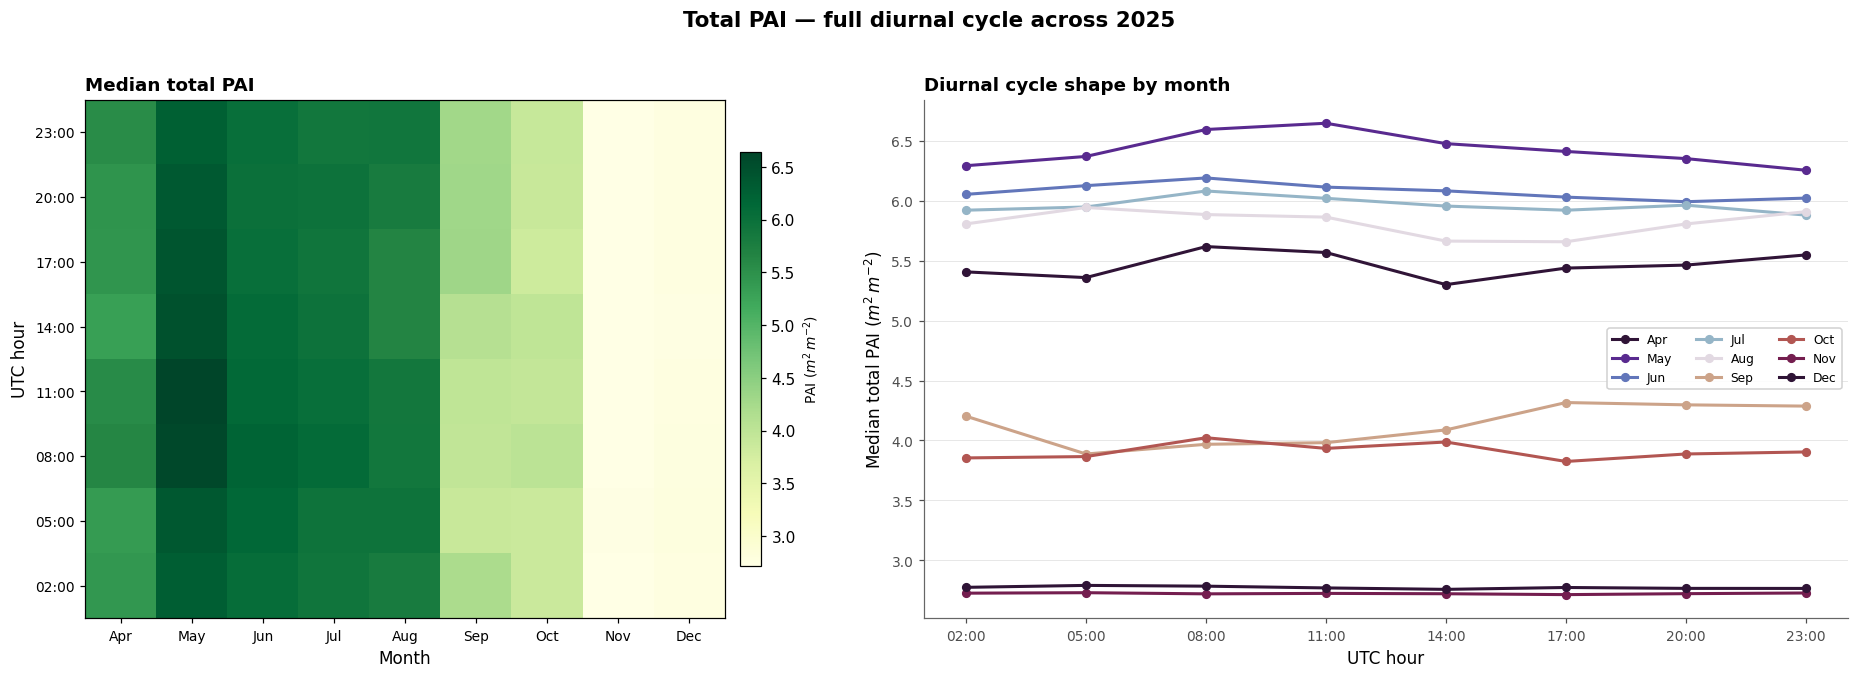

In [92]:
# ── Fig D1: Total PAI — diurnal cycle by month ────────────────────
# Left: heatmap (hour × month), Right: line overlay per month

pivot = df_all.pivot_table(values='pai_total', index='utc_hour',
                           columns='month', aggfunc='median')
month_labels = {m: pd.Timestamp(2025, m, 1).strftime('%b') for m in pivot.columns}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6),
                                gridspec_kw={'width_ratios': [1, 1.2]})
fig.patch.set_facecolor('white')

# --- Left: heatmap ---
im = ax1.imshow(pivot.values, aspect='auto', cmap='YlGn',
                origin='lower', interpolation='nearest')
ax1.set_yticks(range(len(pivot.index)))
ax1.set_yticklabels([f'{h:02d}:00' for h in pivot.index], fontsize=9)
ax1.set_xticks(range(len(pivot.columns)))
ax1.set_xticklabels([month_labels[m] for m in pivot.columns], fontsize=9)
ax1.set_ylabel('UTC hour', fontsize=11)
ax1.set_xlabel('Month', fontsize=11)
ax1.set_title('Median total PAI', fontsize=12, fontweight='bold', loc='left')
cb = fig.colorbar(im, ax=ax1, shrink=0.8, pad=0.02)
cb.set_label(r'PAI ($m^2\,m^{-2}$)', fontsize=9)

# --- Right: line plot per month ---
ax2.set_facecolor('white')
cmap_m = plt.cm.twilight_shifted
norm_m = plt.Normalize(pivot.columns.min(), pivot.columns.max())

for m in pivot.columns:
    color = cmap_m(norm_m(m))
    vals = pivot[m].dropna()
    ax2.plot(vals.index, vals.values, 'o-', color=color, lw=2, ms=5,
             label=month_labels[m])

ax2.set_xticks(ALL_HOURS)
ax2.set_xticklabels([f'{h:02d}:00' for h in ALL_HOURS], fontsize=9)
ax2.set_xlabel('UTC hour', fontsize=11)
ax2.set_ylabel(r'Median total PAI ($m^2\,m^{-2}$)', fontsize=11)
ax2.set_title('Diurnal cycle shape by month', fontsize=12,
              fontweight='bold', loc='left')
ax2.legend(fontsize=8, ncol=3, framealpha=0.9)
ax2.grid(axis='y', color='0.88', lw=0.5)
for sp in ('top', 'right'):
    ax2.spines[sp].set_visible(False)
ax2.spines['left'].set_color('0.4')
ax2.spines['bottom'].set_color('0.4')
ax2.tick_params(colors='0.3', labelsize=9)

fig.suptitle('Total PAI — full diurnal cycle across 2025',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

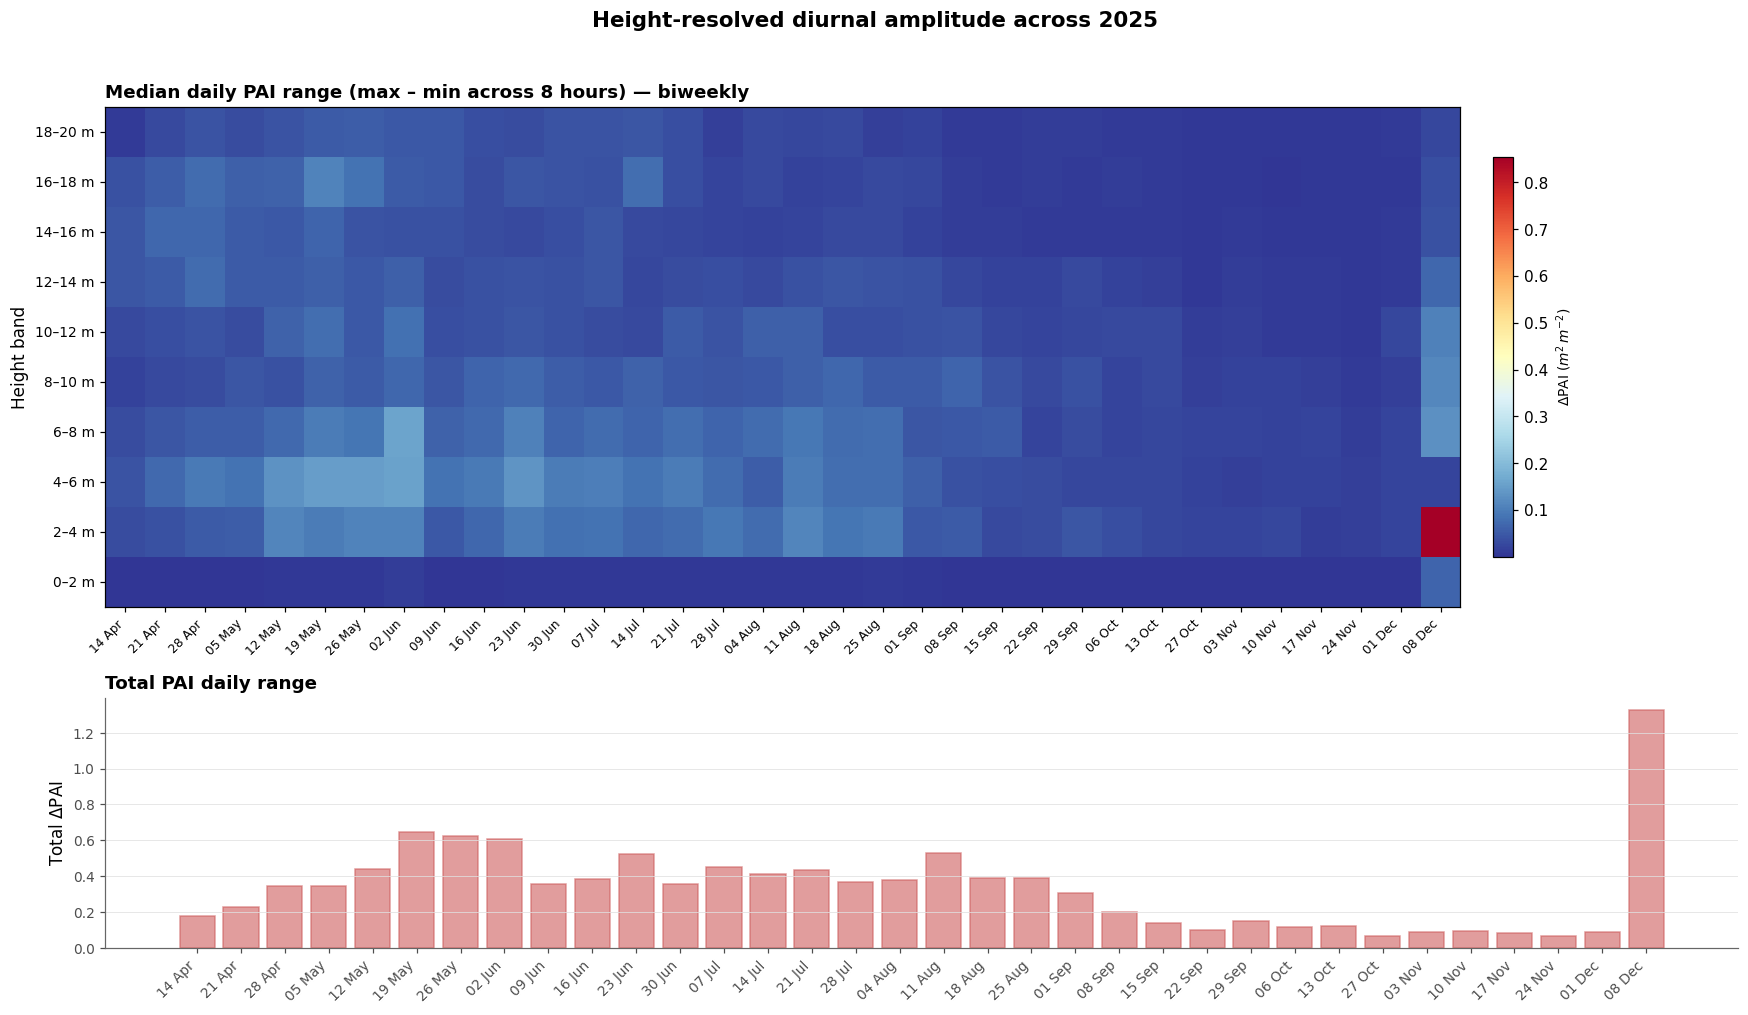

In [93]:
# ── Fig D2: Height-resolved diurnal amplitude — biweekly ──────────
# For each date, compute daily range (max - min across hours) per band.
# Then show as heatmap: x = biweekly period, y = height band.

band_cols = [f'pai_{lo}_{hi}' for lo, hi in DIURNAL_BANDS]
band_labels = [f'{lo}–{hi} m' for lo, hi in DIURNAL_BANDS]

# Daily amplitude = max(hour) - min(hour) for each band
daily_amp = df_all.groupby('date')[band_cols + ['pai_total']].agg(
    lambda x: x.max() - x.min() if len(x) >= 4 else np.nan)
daily_amp.index = pd.to_datetime(daily_amp.index)
daily_amp = daily_amp.loc['2025'].dropna(how='all')

# Biweekly medians
daily_amp['period'] = daily_amp.index.to_period('2W')
biweekly = daily_amp.groupby('period')[band_cols].median()

fig, axes = plt.subplots(2, 1, figsize=(16, 9),
                          gridspec_kw={'height_ratios': [2, 1]})
fig.patch.set_facecolor('white')

# --- Top: heatmap ---
ax = axes[0]
data = biweekly[band_cols].values.T
xlabels = [p.start_time.strftime('%d %b') for p in biweekly.index]

im = ax.imshow(data, aspect='auto', cmap='RdYlBu_r', origin='lower',
               interpolation='nearest')
ax.set_yticks(range(len(band_labels)))
ax.set_yticklabels(band_labels, fontsize=9)
ax.set_xticks(range(len(xlabels)))
ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Height band', fontsize=11)
ax.set_title('Median daily PAI range (max – min across 8 hours) — biweekly',
             fontsize=12, fontweight='bold', loc='left')
cb = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cb.set_label(r'$\Delta$PAI ($m^2\,m^{-2}$)', fontsize=9)

# --- Bottom: total PAI amplitude time series ---
ax2 = axes[1]
ax2.set_facecolor('white')
amp_total = daily_amp.groupby('period')['pai_total'].median()
ax2.bar(range(len(amp_total)), amp_total.values, color='indianred', alpha=0.6,
        edgecolor='indianred')
ax2.set_xticks(range(len(xlabels)))
ax2.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel(r'Total $\Delta$PAI', fontsize=11)
ax2.set_title('Total PAI daily range', fontsize=12,
              fontweight='bold', loc='left')
ax2.grid(axis='y', color='0.88', lw=0.5)
for sp in ('top', 'right'):
    ax2.spines[sp].set_visible(False)
ax2.spines['left'].set_color('0.4')
ax2.spines['bottom'].set_color('0.4')
ax2.tick_params(colors='0.3', labelsize=9)

fig.suptitle('Height-resolved diurnal amplitude across 2025',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

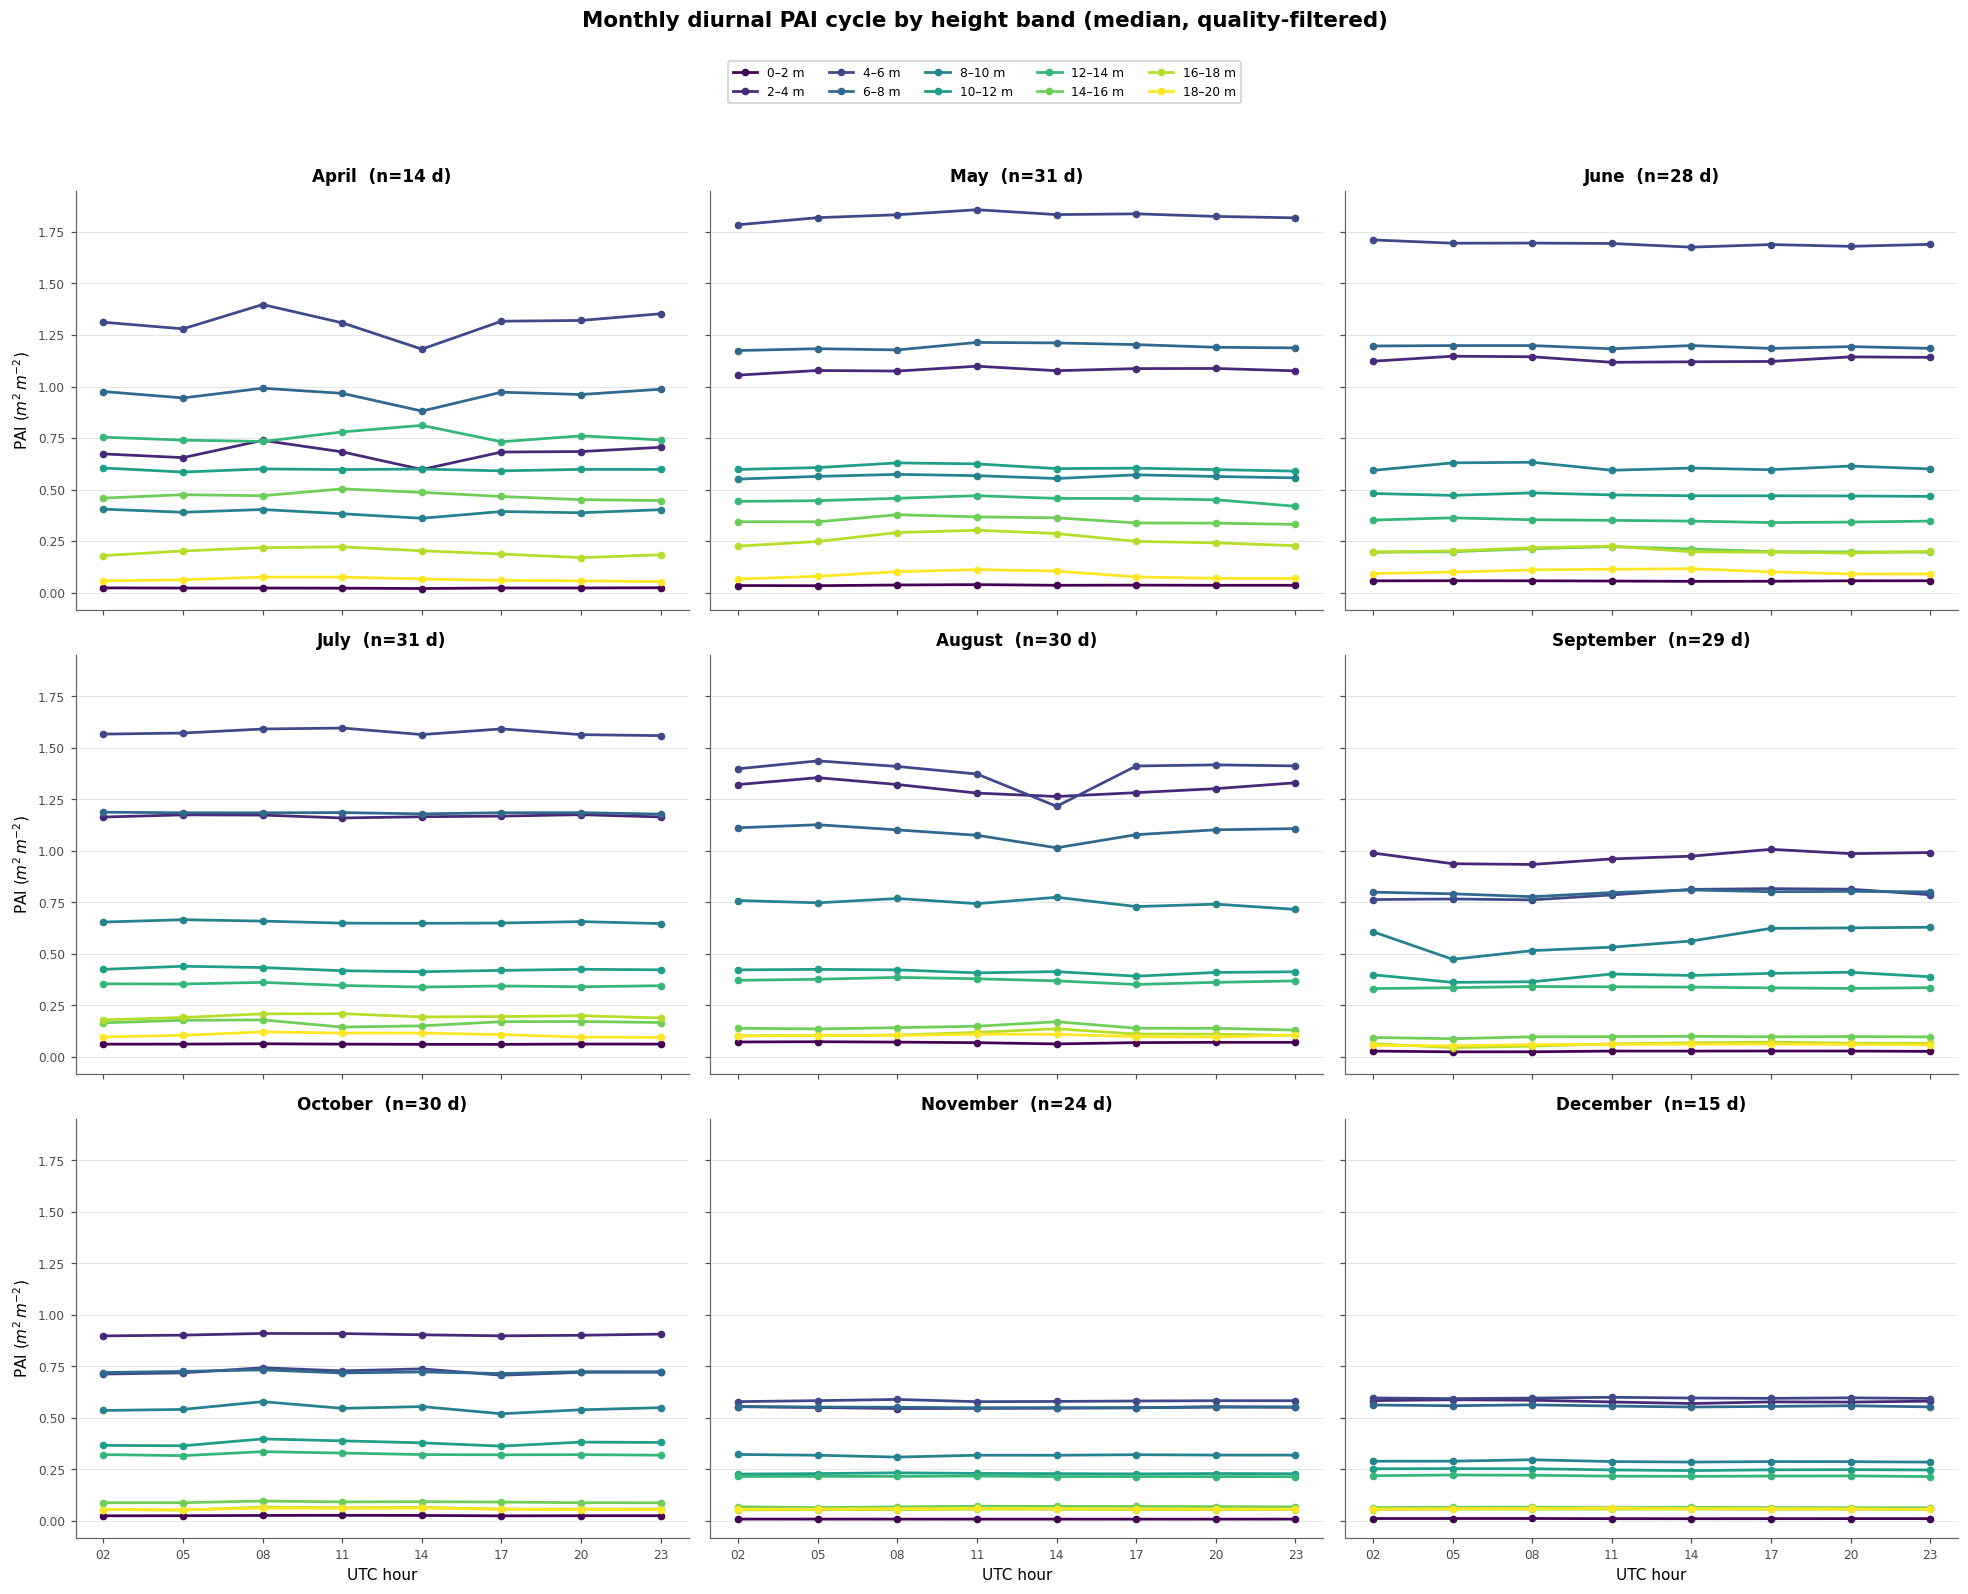

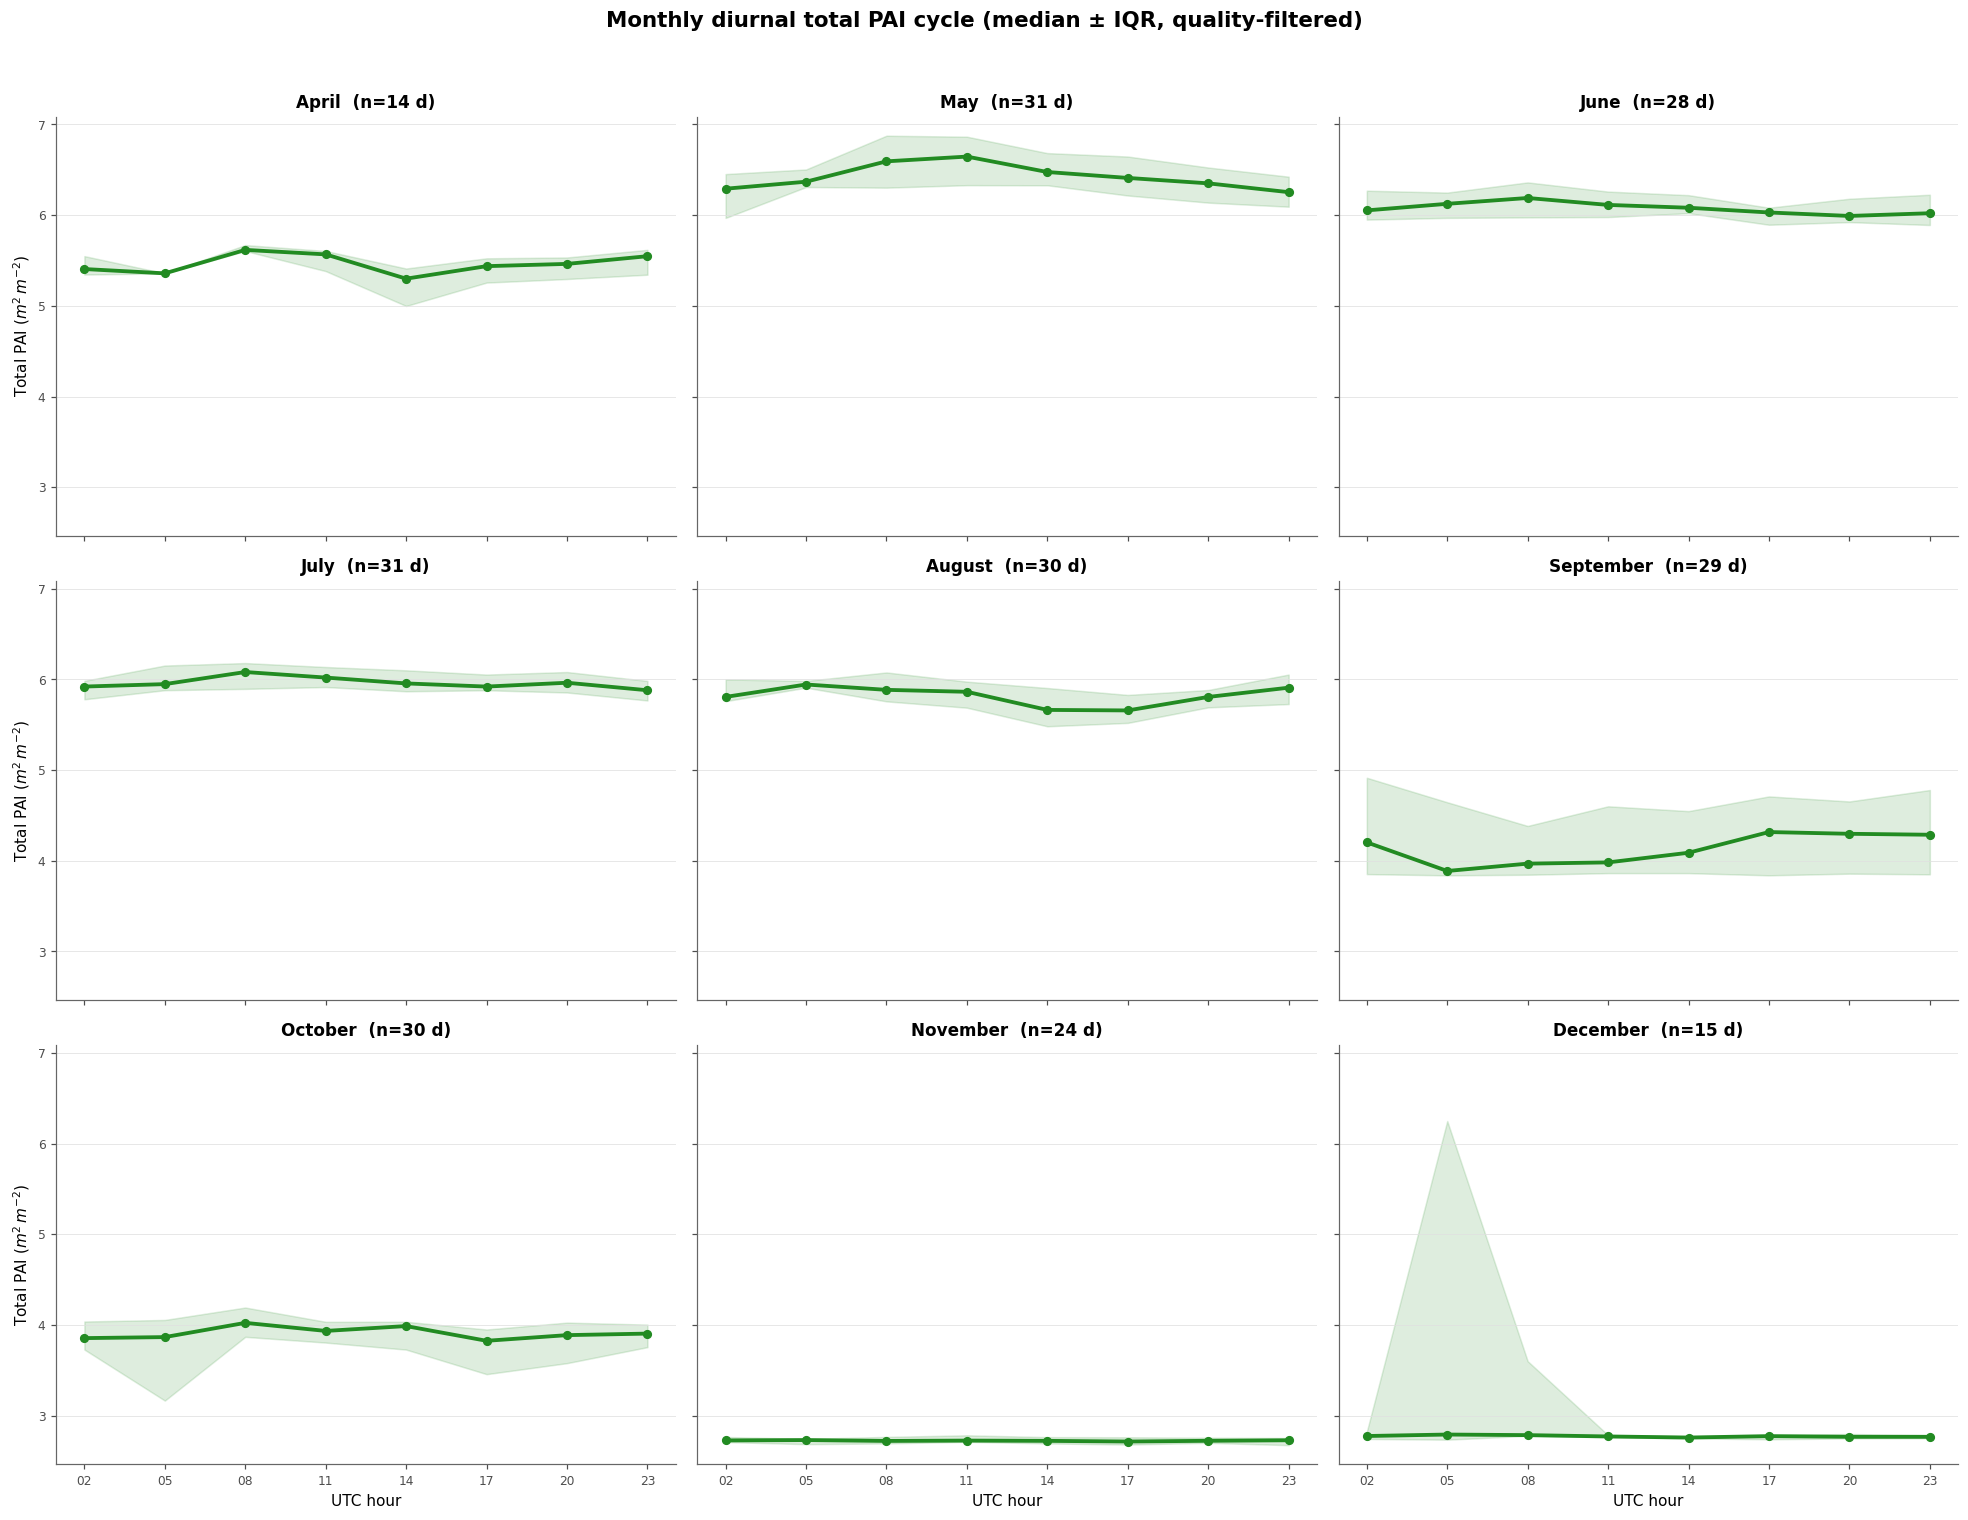

In [94]:
# ── Fig D3: Monthly diurnal cycle by height band ─────────────────
# Small multiples: one panel per month. Within each panel, lines for
# each height band showing median PAI vs UTC hour.

months_present = sorted(df_all['month'].unique())
n_months = len(months_present)
ncols = 3
nrows = int(np.ceil(n_months / ncols))

cmap_h = plt.cm.viridis
norm_h = plt.Normalize(0, len(DIURNAL_BANDS) - 1)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.5 * nrows),
                          sharex=True, sharey=True)
fig.patch.set_facecolor('white')

band_cols = [f'pai_{lo}_{hi}' for lo, hi in DIURNAL_BANDS]
band_labels = [f'{lo}–{hi} m' for lo, hi in DIURNAL_BANDS]

for idx, m in enumerate(months_present):
    ax = axes.flat[idx]
    ax.set_facecolor('white')
    df_m = df_all[df_all['month'] == m]
    month_lbl = pd.Timestamp(2025, m, 1).strftime('%B')
    n_days = df_m['date'].nunique()

    for bi, (col, lbl) in enumerate(zip(band_cols, band_labels)):
        color = cmap_h(norm_h(bi))
        hourly = df_m.groupby('utc_hour')[col].median()
        ax.plot(hourly.index, hourly.values, 'o-', color=color,
                lw=1.8, ms=4, label=lbl if idx == 0 else None)

    ax.set_title(f'{month_lbl}  (n={n_days} d)', fontsize=11, fontweight='bold')
    ax.grid(axis='y', color='0.88', lw=0.5)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color('0.4')
    ax.spines['bottom'].set_color('0.4')
    ax.tick_params(colors='0.3', labelsize=8)

# Hide empty panels
for idx in range(n_months, nrows * ncols):
    axes.flat[idx].set_visible(False)

# Shared labels
for ax in axes[-1, :]:
    if ax.get_visible():
        ax.set_xticks(ALL_HOURS)
        ax.set_xticklabels([f'{h:02d}' for h in ALL_HOURS], fontsize=8)
        ax.set_xlabel('UTC hour', fontsize=10)
for ax in axes[:, 0]:
    ax.set_ylabel(r'PAI ($m^2\,m^{-2}$)', fontsize=10)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5,
           fontsize=8, bbox_to_anchor=(0.5, 1.04), framealpha=0.9)

fig.suptitle('Monthly diurnal PAI cycle by height band (median, quality-filtered)',
             fontsize=14, fontweight='bold', y=1.07)
fig.tight_layout()
plt.show()

# Also show total PAI version
fig2, axes2 = plt.subplots(nrows, ncols, figsize=(18, 4.5 * nrows),
                            sharex=True, sharey=True)
fig2.patch.set_facecolor('white')

for idx, m in enumerate(months_present):
    ax = axes2.flat[idx]
    ax.set_facecolor('white')
    df_m = df_all[df_all['month'] == m]
    month_lbl = pd.Timestamp(2025, m, 1).strftime('%B')
    n_days = df_m['date'].nunique()

    hourly = df_m.groupby('utc_hour')['pai_total'].agg(['median', 'quantile'])
    med = df_m.groupby('utc_hour')['pai_total'].median()
    q25 = df_m.groupby('utc_hour')['pai_total'].quantile(0.25)
    q75 = df_m.groupby('utc_hour')['pai_total'].quantile(0.75)

    ax.fill_between(med.index, q25.values, q75.values,
                    color='forestgreen', alpha=0.15)
    ax.plot(med.index, med.values, 'o-', color='forestgreen',
            lw=2.5, ms=5)

    ax.set_title(f'{month_lbl}  (n={n_days} d)', fontsize=11, fontweight='bold')
    ax.grid(axis='y', color='0.88', lw=0.5)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color('0.4')
    ax.spines['bottom'].set_color('0.4')
    ax.tick_params(colors='0.3', labelsize=8)

for idx in range(n_months, nrows * ncols):
    axes2.flat[idx].set_visible(False)

for ax in axes2[-1, :]:
    if ax.get_visible():
        ax.set_xticks(ALL_HOURS)
        ax.set_xticklabels([f'{h:02d}' for h in ALL_HOURS], fontsize=8)
        ax.set_xlabel('UTC hour', fontsize=10)
for ax in axes2[:, 0]:
    ax.set_ylabel(r'Total PAI ($m^2\,m^{-2}$)', fontsize=10)

fig2.suptitle('Monthly diurnal total PAI cycle (median ± IQR, quality-filtered)',
              fontsize=14, fontweight='bold', y=1.02)
fig2.tight_layout()
plt.show()

In [95]:
# ── Pairwise amplitude: which two scan times give the strongest ΔPAI?
from itertools import combinations

# Pivot: one column per hour, one row per date, value = median PAI (total)
piv = df_all.pivot_table(values='pai_total', index='date',
                         columns='utc_hour', aggfunc='median')
# Only dates with at least 6 of 8 hours present
piv = piv.dropna(thresh=6)

print(f'Complete-ish days: {len(piv)}\n')
print(f'{"Hour A":>8} {"Hour B":>8}  {"median ΔPAI":>12}  {"mean ΔPAI":>10}  {"n days":>7}')
print('-' * 55)

pair_stats = []
for h_early, h_late in combinations(ALL_HOURS, 2):
    diff = piv[h_early] - piv[h_late]
    diff = diff.dropna()
    if len(diff) < 10:
        continue
    pair_stats.append({
        'h_early': h_early, 'h_late': h_late,
        'median': diff.median(), 'mean': diff.mean(),
        'n': len(diff),
    })

pair_stats.sort(key=lambda x: abs(x['median']), reverse=True)

for ps in pair_stats:
    marker = '  ◄' if ps is pair_stats[0] else ''
    print(f"  {ps['h_early']:02d}:00   {ps['h_late']:02d}:00  "
          f"{ps['median']:+.4f}       {ps['mean']:+.4f}     {ps['n']:>4}{marker}")

best = pair_stats[0]
print(f"\n★ Strongest amplitude: {best['h_early']:02d}:00 vs {best['h_late']:02d}:00 UTC "
      f"(median ΔPAI = {best['median']:+.4f})")

# Same analysis per height band
print('\n\nBest pair per height band:')
print(f'{"Band":>10}  {"Hour A":>8} {"Hour B":>8}  {"median ΔPAI":>12}')
print('-' * 50)

for lo, hi in DIURNAL_BANDS:
    col = f'pai_{lo}_{hi}'
    piv_b = df_all.pivot_table(values=col, index='date',
                               columns='utc_hour', aggfunc='median')
    piv_b = piv_b.dropna(thresh=6)

    best_pair, best_med = None, 0
    for h1, h2 in combinations(ALL_HOURS, 2):
        diff = (piv_b[h1] - piv_b[h2]).dropna()
        if len(diff) < 10 and abs(diff.median()) > abs(best_med):
            continue
        med = diff.median()
        if abs(med) > abs(best_med):
            best_med = med
            best_pair = (h1, h2)

    if best_pair:
        print(f'  {lo:>2}–{hi:<2} m   {best_pair[0]:02d}:00   {best_pair[1]:02d}:00  '
              f'{best_med:+.4f}')
    else:
        print(f'  {lo:>2}–{hi:<2} m   —')

Complete-ish days: 127

  Hour A   Hour B   median ΔPAI   mean ΔPAI   n days
-------------------------------------------------------
  08:00   17:00  +0.0872       +0.1683      106  ◄
  08:00   23:00  +0.0590       +0.1825      101
  11:00   17:00  +0.0538       +0.0469      105
  08:00   20:00  +0.0494       +0.0864      104
  11:00   20:00  +0.0374       -0.0345      103
  11:00   23:00  +0.0373       +0.0446      101
  02:00   08:00  -0.0345       -0.1145       97
  05:00   20:00  +0.0342       +0.1239       93
  05:00   23:00  +0.0341       +0.2387       90
  02:00   11:00  -0.0316       +0.0122       96
  14:00   23:00  +0.0292       +0.0327       95
  05:00   17:00  +0.0290       +0.2212       95
  05:00   08:00  -0.0271       +0.0397       87
  02:00   17:00  +0.0225       +0.0595      113
  08:00   14:00  +0.0224       +0.1870       87
  17:00   20:00  -0.0211       -0.0780      120
  05:00   11:00  -0.0157       +0.2067       80
  14:00   20:00  +0.0146       -0.0725       97
